# <font color='blue'> 기계학습을 이용한 해외제조가공업소의 현지실사 프로세스 효율화 방안
<img src = 'https://images.unsplash.com/photo-1501290741922-b56c0d0884af?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxzZWFyY2h8Mnx8cmVzZWFyY2h8ZW58MHx8MHx8&auto=format&fit=crop&w=500&q=60'>

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

## 현지실사과(식약처) 현지실사 계획 수입 방법(계획실사 : 년간 1회)
### 1. 과거 5년동안 수입민원정보를 참고하고 
### 2. 최근 1년간의 수입민원정보에서 업체별 통계(부적합률, 수입빈도 및 물량 등)와
### 3. 수거검사시 적발된 제품의 업체정보를 파악하여 매년 9~10월에 차년도 현지실사계획 수립

### 기획 현지실사는 민원(Complaint) 등으로 수행(중국 김치공장 전수조사)

# 수입식품안전관리 특별법 ( 약칭: 수입식품법 )
수입식품안전관리 특별법
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=234855#0000
   
수입식품안전관리 특별법 시행령
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220218&lsiSeq=240329#0000

수입식품안전관리 특별법 시행규칙
https://www.law.go.kr/LSW/lsInfoP.do?efYd=20220701&lsiSeq=233697#0000
   ** 수입민원신고서([별지 제25호서식] 수입식품등의 수입신고서)

## 해외제조업소 등록신청서
### 해외제조가공업소 기본 속성 정보
법 제5조(해외제조업소 등록) ① 수입식품등을 국내로 수입하려는 자 또는 해외제조업소의 설치ㆍ운영자(이하 “수입자등”이라 한다)는 해당 해외제조업소의 명칭, 소재지 및 생산 품목 등 총리령으로 정하는 사항을 제20조에 따른 수입신고 전까지 식품의약품안전처장에게 등록하여야 한다.

<img src='https://www.law.go.kr/LSW/flDownload.do?flSeq=113540777'>

### 해외제조업소 점검표 (별표2 삭제)
법 제6조(해외제조업소의 현지실사) ① 식품의약품안전처장은 다음 각 호의 어느 하나에 해당하는 경우에는 수출국 정부 또는 해외제조업소와 사전에 협의를 거쳐 해외제조업소에 대하여 현지실사를 할 수 있다.

In [3]:
def summary(df) :
    tf = pd.DataFrame({'데이터형태(dtypes)' : df.dtypes,
                       '결측치 수(null)' : df.isnull().sum(),
                       '결측치 비율(%)' : (df.isnull().sum()/len(df)).round(2),
                       '고유값 수(nunique)' : df.nunique(),
                      })
    for col in tf.index:
        tf.loc[col, '자료 내용(contents)'] = str(df[col].unique()[0:5])
        
    return tf

# 1. 데이터 확보
## 데이터 전처리 완료

In [4]:
import glob
path = r'D:\smart food\현지실사\2022_2_현지실사\working'
file_list = glob.glob(path + '/*.*')
file_list

['D:\\smart food\\현지실사\\2022_2_현지실사\\working\\11. 대장_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\12. 대장_변경내역_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\13. 관리시스템_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\14. 품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\15. 식품_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\16. 중단품목_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\17. 중단(수입)_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\18. 영업종류_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\22. 수입민원_업소별_품목특성_gzip',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\33. WorldBank_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\41. 품목코드_특성_gzip.pkl',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working\\51. 현지실사결과_gzip.pkl']

In [5]:
'''
for file in file_list:
    print('파일이름 : ', file)
    pd.read_pickle(file, compression='gzip').head(2)
    print('*'*200)
'''''

"\nfor file in file_list:\n    print('파일이름 : ', file)\n    pd.read_pickle(file, compression='gzip').head(2)\n    print('*'*200)\n"

## MCA 2차원 축소 시각화

In [6]:
import prince

def mca_visulaization(df):
    input_X = df.copy()
    mca = prince.MCA(n_components=2).fit(input_X)
    ax = mca.plot_coordinates(X = input_X, figsize=(20, 6), show_column_labels=True)
    ax.set_title("Correspondence analysis", fontsize = 18)

In [7]:
from sklearn.tree import DecisionTreeClassifier

def visual_predict_tree(data):
    X = data.drop(['target'], axis=1)
    y = data.target
    cassifier = DecisionTreeClassifier()
    cassifier.fit(X, y)
    plt.figure(figsize=(25,8))
    ax = plot_tree(cassifier, filled=True)
    #plt.legend(loc='lower right', borderpad=0, handletextpad=0)

## 1.1. CO_IFD_OVSMNFST_REGSTR_M 
수입식품 해외제조업소 대장
국가, 업소명, 대표자명, 주소, 전화번호, 이메일, 팩스번호, 인증, E42_취소_중단_코드 등 16개 특성변수

## 전체데이터가 아닌 현지실사 대상 데이터만 추출

In [8]:
path = r'D:\smart food\현지실사\2022_2_현지실사\working_ml'
df = pd.read_pickle(path + '/data_01_대장.pkl').set_index('해외제조업소_코드').drop('A02_국가코드', axis=1)
df.head()
df.shape

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,R,S,Y,target
해외제조업소_코드,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
CN000010833,True,True,True,True,True,False,False,False,False,False,True,False,False,False,False
VN000000420,True,True,True,True,True,True,True,False,False,False,True,False,False,False,False
JP000002818,True,True,True,True,True,True,False,False,False,False,True,False,False,False,False
TH000001271,True,True,True,True,True,False,True,True,True,False,False,False,False,True,False


(1689, 15)

## 의사결정트리로 예측하기

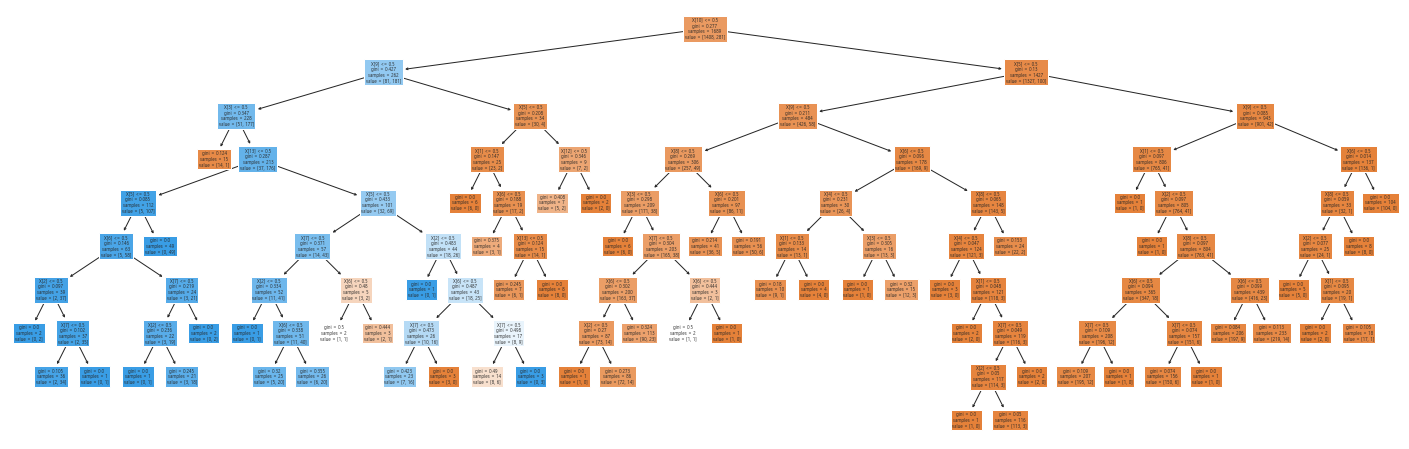

In [9]:
visual_predict_tree(df)

In [10]:
'''# A02_국가코드 컬럼에 31개의 null값이 존재
df = pd.read_pickle(file_list[0], compression='gzip').drop('A02_국가코드', axis=1)
df
df.isnull().sum().sum()
'''

"# A02_국가코드 컬럼에 31개의 null값이 존재\ndf = pd.read_pickle(file_list[0], compression='gzip').drop('A02_국가코드', axis=1)\ndf\ndf.isnull().sum().sum()\n"

## 1.2. CO_IFD_OVSMNFST_REGSTR_CHNG_H 
수입식품 해외제조업소 대장 변경내역
신규변경과 갱신여부 등 36개 특성변수 

In [11]:
tf = pd.read_pickle(file_list[1], compression='gzip')
tf.isnull().sum().sum()
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

0

,해외제조업소_코드,new_01,new_02,new_03,new_04,new_05,new_06,new_07,new_08,new_09,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
0,014566,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,017426,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,017620,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,021823,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,023215,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18235,ZA000001913,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18236,ZA000001920,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
18237,ZA000001928,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18238,ZA000001948,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


### 10개의 변수만 가지고 MCA 그래프 시각화

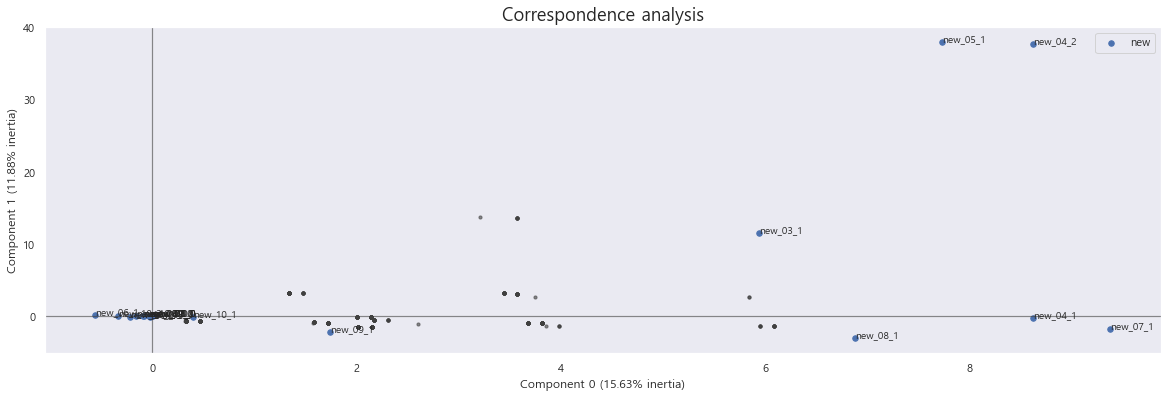

In [12]:
mca_visulaization(tf.set_index('해외제조업소_코드').iloc[:, 0:10].astype('category'))

In [13]:
df = pd.merge(df, tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
df

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [14]:
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_09,modify_10,modify_11,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


DecisionTreeClassifier()

<Figure size 1800x576 with 0 Axes>

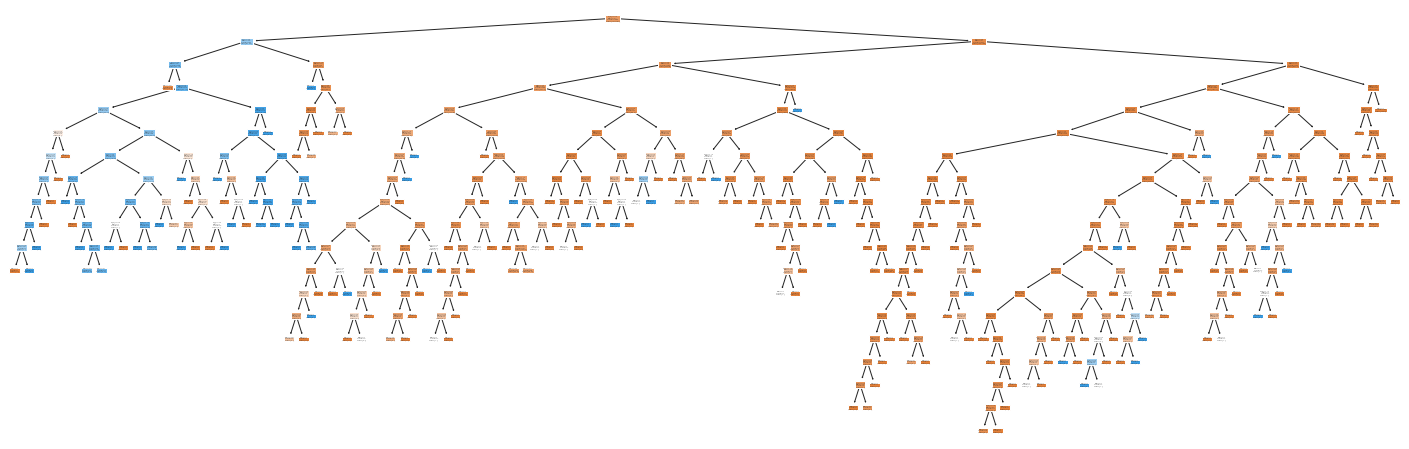

In [15]:
y = df.target
dt = DecisionTreeClassifier()
dt.fit(X, y)
plt.figure(figsize=(25,8))
ax = plot_tree(dt, filled=True)

In [16]:
from sklearn.model_selection import cross_val_score, cross_validate
cross_val_score(dt, X, y, cv=5)
pd.DataFrame(cross_validate(dt, X, y, 
               scoring=['accuracy', 'roc_auc', 'average_precision', 'recall'], 
               return_train_score=True))

array([0.8816568 , 0.88757396, 0.89349112, 0.84319527, 0.88724036])

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_average_precision,train_average_precision,test_recall,train_recall
0,0.010971,0.010971,0.878698,0.951147,0.812310,0.971109,0.479984,0.902888,0.607143,0.746667
1,0.010001,0.008949,0.884615,0.943005,0.791255,0.969564,0.463569,0.892780,0.625000,0.706667
2,0.008006,0.007979,0.875740,0.948187,0.830230,0.969455,0.460447,0.892837,0.607143,0.737778
3,0.007977,0.007975,0.857988,0.943005,0.735874,0.966750,0.398436,0.887071,0.631579,0.705357
4,0.007978,0.007983,0.887240,0.946746,0.798805,0.967662,0.515347,0.892393,0.535714,0.733333


### MCA를 이용한 차원축소

In [17]:
input_X = tf.set_index('해외제조업소_코드').astype('category').copy()
mca = prince.MCA(n_components=2).fit(input_X)
mca.transform(input_X)

,0,1
014566,0.045485,-0.125286
017426,-0.000471,-0.177459
017620,-0.000471,-0.177459
021823,0.082453,-0.063866
023215,-0.107960,-0.094921
...,...,...
ZA000001913,-0.152956,-0.105592
ZA000001920,-0.080794,-0.149429
ZA000001928,-0.143672,-0.184503
ZA000001948,-0.101272,-0.032480


## 1.3. CO_IFD_OVSMNFST_MNGSYS_D 
수입식품 해외제조업소 관리시스템
식품안전관리시스템 구분코드 3개 특성변수


In [18]:
tf = pd.read_pickle(file_list[2], compression='gzip')
tf.isnull().sum().sum()
tf

0

E39_식품안전관리시스템_구분_코드,인증_1,인증_2,인증_3
해외제조업소_코드,,,
027304,True,False,False
029333,True,True,False
039292,True,False,True
AE000000002,False,False,True
AE000000003,True,False,True
...,...,...,...
ZA000001951,False,False,True
ZA000001959,False,False,True
ZA000001970,False,False,True


In [19]:
df.reset_index(inplace=True)

In [20]:
df = pd.merge(df, tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


In [21]:
cross_val_score(dt, X, y, cv=5)

df

array([0.86094675, 0.89053254, 0.88757396, 0.84615385, 0.884273  ])

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


## 1.4. CO_IFD_OVSMNFST_ITM_D 
수입식품 해외제조업소 품목
기능성원료, 수입식품생성, 유통관리대상, 수산부산물, 신고구분 및 품목유형 등 22개 특성변수


In [22]:
tf = pd.read_pickle(file_list[3], compression='gzip')
tf.isnull().sum().sum()
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

0

,해외제조업소_코드,기능성원료,수입식품생성,유통관리대상,수산부산물,ANIMALMDCN,SEPARUSE,MIXTR,신고구분_1,신고구분_2,...,신고구분_6,신고구분_7,신고구분_8,품목_A,품목_B,품목_C,품목_D,품목_E,품목_F,품목_Z
0,AE000000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,AE000000003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,AE000000006,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,AE000000008,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,AE000000111,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58187,ZA000001976,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
58188,ZM000000001,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
58189,ZM000000002,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
58190,ZM000000003,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


In [23]:
df

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,modify_12,modify_13,modify_14,modify_15,modify_16,modify_17,modify_42,인증_1,인증_2,인증_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
CN000010833,True,True,True,True,True,False,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
VN000000420,True,True,True,True,True,True,True,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
JP000002818,True,True,True,True,True,True,False,False,False,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2,2,2
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,2.0,1.0,0.0,0.0,0.0,0.0,True,False,False
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,True
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,False,False,True


In [24]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,신고구분_6,신고구분_7,신고구분_8,품목_A,품목_B,품목_C,품목_D,품목_E,품목_F,품목_Z
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [25]:
cross_val_score(dt, X, y, cv=5)

array([0.85207101, 0.87573964, 0.89053254, 0.73076923, 0.88130564])

## 1.5. CO_IFD_OVSMNFST_FOOD_D 
수입식품 해외제조업소 식품
식품과 수산물 코드로 9개 특성변수(년도별)


In [26]:
tf = pd.read_pickle(file_list[4], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
해외제조업소_코드,연도,,,,,,,,,
AE000000002,2020,False,True,False,False,False,False,False,False,False
AE000000003,2020,False,True,False,False,False,False,False,False,False
AE000000006,2020,False,True,False,False,True,False,False,False,False
AE000000007,2020,False,False,False,False,True,False,False,False,False
AE000000008,2020,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
ZZ000000028,2020,False,False,False,True,False,False,False,False,False
ZZ000000029,2020,False,False,False,True,False,False,False,False,False
ZZ000000030,2020,False,False,False,True,False,False,False,False,False


In [27]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf

,해외제조업소_코드,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
0,AE000000002,0,1,0,0,0,0,0,0,0
1,AE000000003,0,1,0,0,0,0,0,0,0
2,AE000000006,0,1,0,0,1,0,0,0,0
3,AE000000007,0,0,0,0,1,0,0,0,0
4,AE000000008,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
115949,ZZ000000028,0,0,0,1,0,0,0,0,0
115950,ZZ000000029,0,0,0,1,0,0,0,0,0
115951,ZZ000000030,0,0,0,1,0,0,0,0,0
115952,ZZ000000031,0,0,0,1,0,0,0,0,0


In [28]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,품목_Z,식품코드_1,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


array([0.86094675, 0.82840237, 0.85207101, 0.72485207, 0.87833828])

## 1.6. CO_IFD_OVSMNFST_DSCNTC_ITM_D 
수입식품 해외제조업소 중단 품목
중단해제, 중단중 2개 특성변수(년도별)

In [29]:
tf = pd.read_pickle(file_list[5], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,중단해제,중단중
해외제조업소_코드,연도,,
AU000000627,2016,6,0
AU000000693,2021,11,0
BD000000005,2016,6,0
BD000000116,2016,6,0
BD000000134,2016,6,0
...,...,...,...
VN000008897,2016,0,6
VN000008898,2016,0,6
VN000008900,2016,0,6


In [30]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf
tf.describe()

,해외제조업소_코드,중단해제,중단중
0,AU000000627,6,0
1,AU000000693,11,0
2,BD000000005,6,0
3,BD000000116,6,0
4,BD000000134,6,0
...,...,...,...
525,VN000008906,0,6
526,VN000008907,0,6
527,VN000009030,11,0
528,VN000009249,11,0


,중단해제,중단중
count,530.00000,530.000000
mean,3.69434,1.711321
std,2.48948,13.426326
min,0.00000,0.000000
25%,3.00000,0.000000
50%,3.00000,0.000000
75%,6.00000,0.000000
max,11.00000,240.000000


In [32]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,식품코드_2,식품코드_3,식품코드_4,식품코드_5,식품코드_6,수산물코드_1,수산물코드_2,수산물코드_3,중단해제,중단중
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


array([0.87278107, 0.86390533, 0.87278107, 0.78402367, 0.884273  ])

## 1.7. CO_IFD_OVSMNFST_DSCNTC_D 
수입식품 해외제조업소 중단
중단코드 4개 특성변수(년도별)

## 1.8. CO_IFD_OVSMNFST_BZKND_D 
수입식품 해외제조업소 영업종류
영업구분과 ARG 구분으로 11개 특성변수


In [33]:
tf = pd.read_pickle(file_list[7], compression='gzip')
tf.isnull().sum().sum()
tf

0

,,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,연도,,,,,,,,,,,
014566,2020,True,False,False,False,True,False,False,False,False,False,False
015002,2020,False,False,False,False,True,False,False,False,False,False,False
016235,2020,False,False,False,False,True,False,False,False,False,False,False
016248,2020,True,False,False,False,False,False,False,False,False,False,False
017426,2020,True,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
ZM000000001,2021,False,False,True,False,False,False,False,False,False,False,False
ZM000000002,2021,True,False,False,False,False,False,False,False,False,False,False
ZM000000003,2020,False,False,True,False,False,False,False,False,False,False,False


In [34]:
tf = tf.groupby('해외제조업소_코드').sum().reset_index()
tf
#tf.describe()

,해외제조업소_코드,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
0,014566,1,0,0,0,1,0,0,0,0,0,0
1,015002,0,0,0,0,1,0,0,0,0,0,0
2,016235,0,0,0,0,1,0,0,0,0,0,0
3,016248,1,0,0,0,0,0,0,0,0,0,0
4,017426,1,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
89085,ZM000000001,0,0,1,0,0,0,0,0,0,0,0
89086,ZM000000002,1,0,0,0,0,0,0,0,0,0,0
89087,ZM000000003,0,0,1,0,0,0,0,0,0,0,0
89088,ZM000000004,1,0,0,0,0,0,0,0,0,0,0


,영업구분_1,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
count,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000,89090.000000
mean,0.554956,0.293636,0.170592,0.042249,0.101010,0.000382,0.001369,0.000382,0.000763,0.000112,0.000045
std,0.496973,0.455430,0.376154,0.201159,0.301344,0.019532,0.036980,0.019532,0.027617,0.010594,0.006701
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
df = pd.merge(df.reset_index('해외제조업소_코드'), tf, on = '해외제조업소_코드', how='left').fillna(2).set_index('해외제조업소_코드')
X = df.drop('target', axis=1).astype('category')
X
cross_val_score(dt, X, y, cv=5)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


array([0.86686391, 0.85502959, 0.86094675, 0.75147929, 0.884273  ])

# 2. 특성변수 추출
### Feature selection

### Theil_U

In [179]:
import math
import scipy.stats as ss
from collections import Counter

def conditional_entropy(x,y):
    # entropy of x given y
    y_counter = Counter(y)
    xy_counter = Counter(list(zip(x,y)))
    total_occurrences = sum(y_counter.values())
    entropy = 0
    for xy in xy_counter.keys():
        p_xy = xy_counter[xy] / total_occurrences
        p_y = y_counter[xy[1]] / total_occurrences
        entropy += p_xy * math.log(p_y/p_xy)
    return entropy

def theil_u(x,y):
    s_xy = conditional_entropy(x,y)
    x_counter = Counter(x)
    total_occurrences = sum(x_counter.values())
    p_x = list(map(lambda n: n/total_occurrences, x_counter.values()))
    s_x = ss.entropy(p_x)
    if s_x == 0:
        return 1
    else:
        return (s_x - s_xy) / s_x

In [180]:
def cat_corr (df):
    
    for j in range(0,len(columns)):
        u = theil_u(df['target'].tolist(),df[columns[j]].tolist())
        theilu.loc[:,columns[j]] = u
    theilu.fillna(value=np.nan,inplace=True)
    
    plt.figure(figsize=(30,2))
    sns.set(font_scale=1.4)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    sns.heatmap(theilu,annot=True,fmt='.1f', annot_kws={"size": 10})

    plt.show()
    return theilu

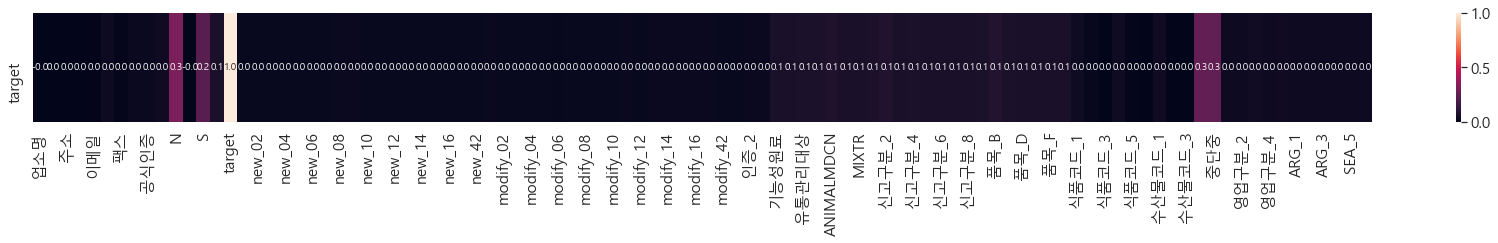

In [181]:
columns = df.columns
theilu = pd.DataFrame(index=['target'], columns= columns)

theilu = cat_corr(df)

<AxesSubplot:>

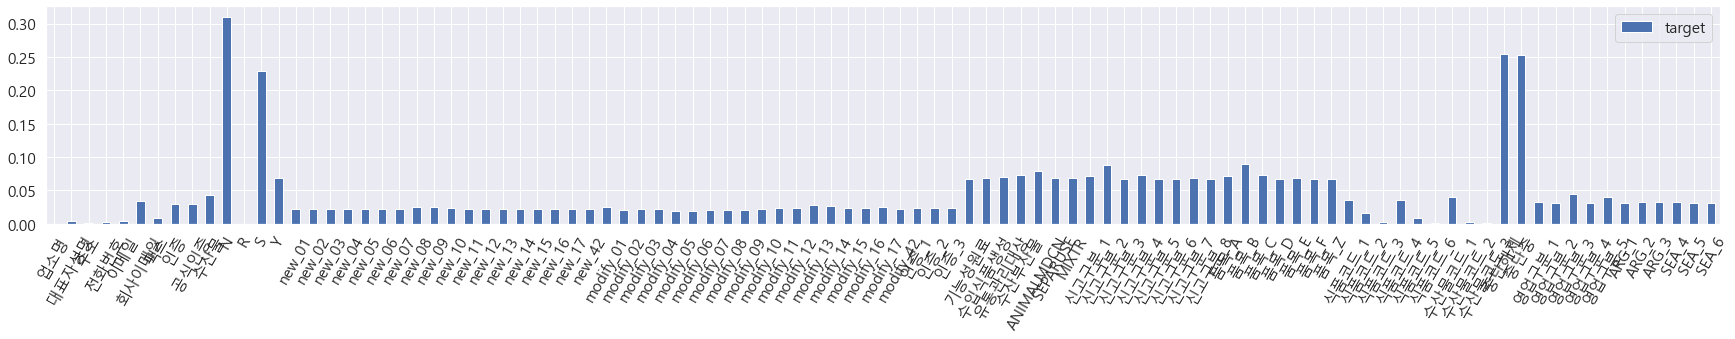

In [182]:
theilu.drop('target', axis=1).T.plot(kind='bar', rot='60', figsize=(30,4))

<AxesSubplot:>

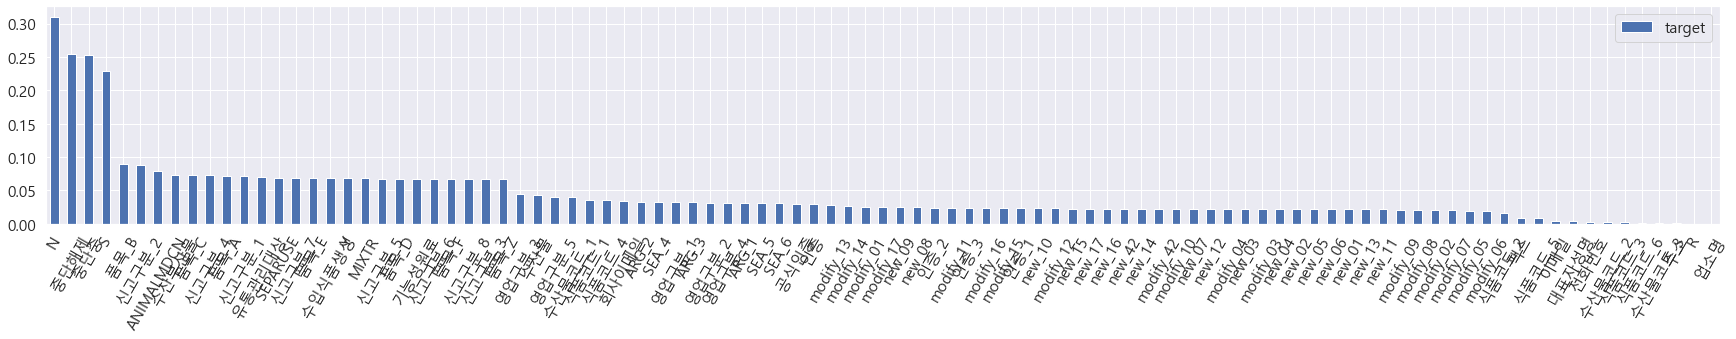

In [187]:
theilu.drop('target', axis=1).T.sort_values('target', ascending=False).plot(kind='bar', rot='60', figsize=(30,4))

## EDA

In [247]:
def smallPlots(col, title, i):
    plot_data = df.reset_index().reset_index().groupby([col, 'target']).agg({'index':'count'}).reset_index()
    sns.barplot(x=plot_data[col],
              y=plot_data['index'],
              hue=plot_data['target'], ax= ax[i])
    ax[i].set_title(title)

### 2.1. 부적합에 영향이 큰 변수

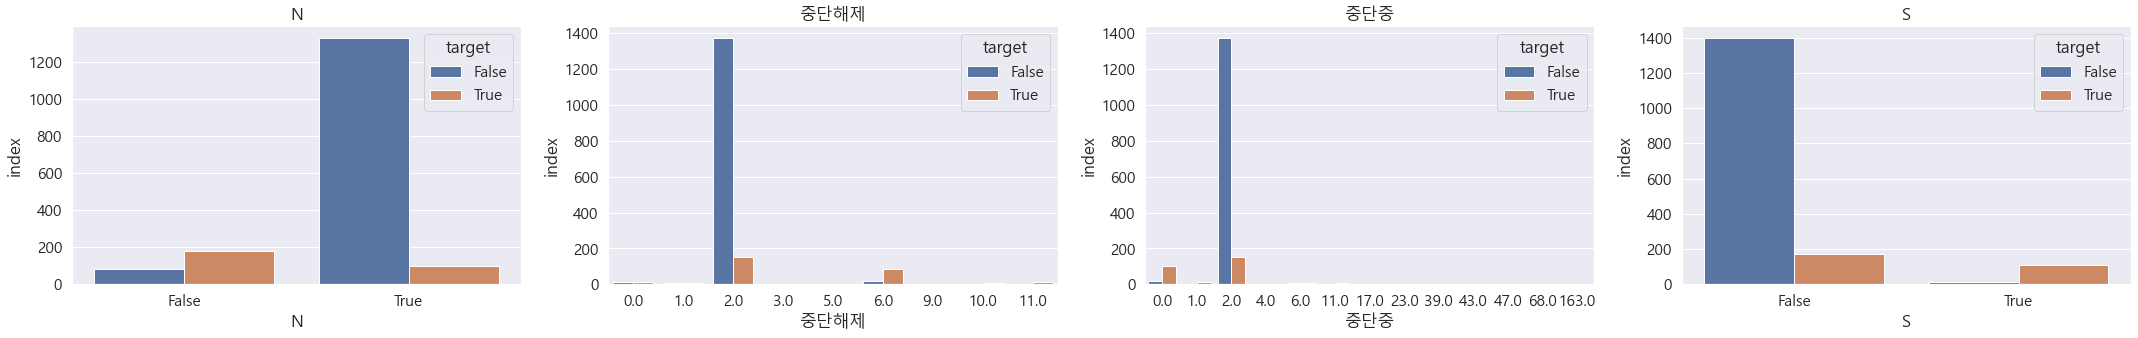

In [252]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30,5))

top_vars = theilu.drop('target', axis=1).T.sort_values('target', ascending=False).index

smallPlots(top_vars[0] , str(top_vars[0]), 0)
smallPlots(top_vars[1] , str(top_vars[1]), 1)
smallPlots(top_vars[2], str(top_vars[2]), 2)
smallPlots(top_vars[3], str(top_vars[3]), 3)

fig.tight_layout()
plt.show()

### 2.2. 부적합에 영향이 적은 변수
- 업소명과 R 변수는 특성변수에서 제외(카이제고갑솨 teilu값이 0)

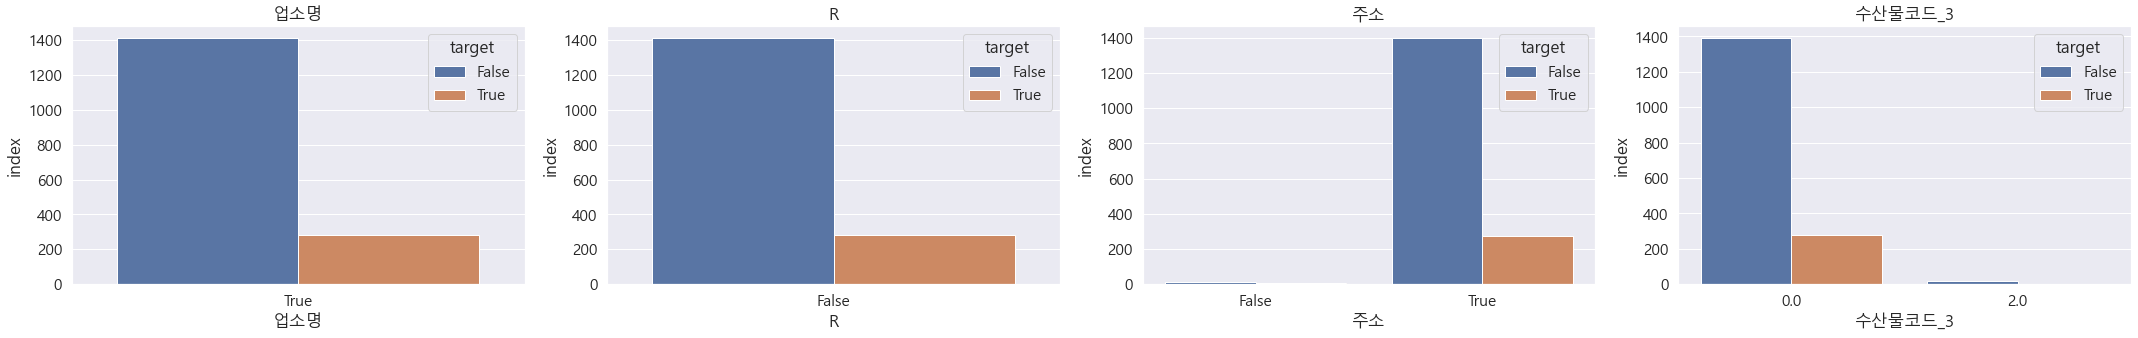

In [253]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(30,5))

top_vars = theilu.drop('target', axis=1).T.sort_values('target', ascending=True).index

smallPlots(top_vars[0] , str(top_vars[0]), 0)
smallPlots(top_vars[1] , str(top_vars[1]), 1)
smallPlots(top_vars[2], str(top_vars[2]), 2)
smallPlots(top_vars[3], str(top_vars[3]), 3)

fig.tight_layout()
plt.show()

### 2.3. 부적합에 영향이 적은 변수로 MCA 차원축소 대상 변수

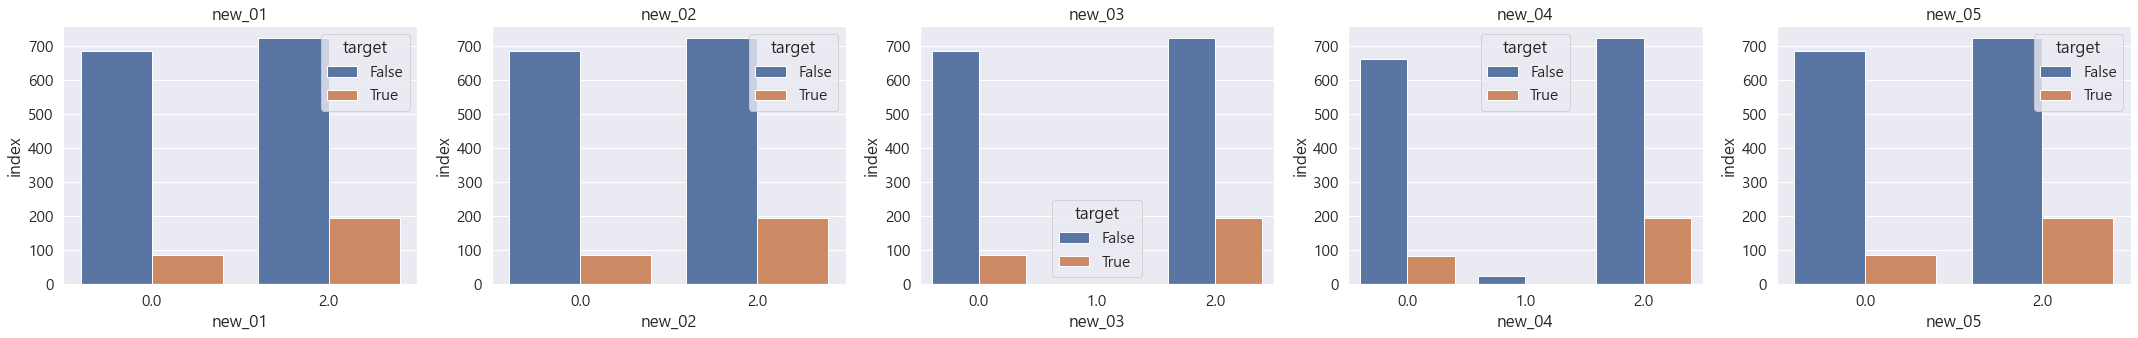

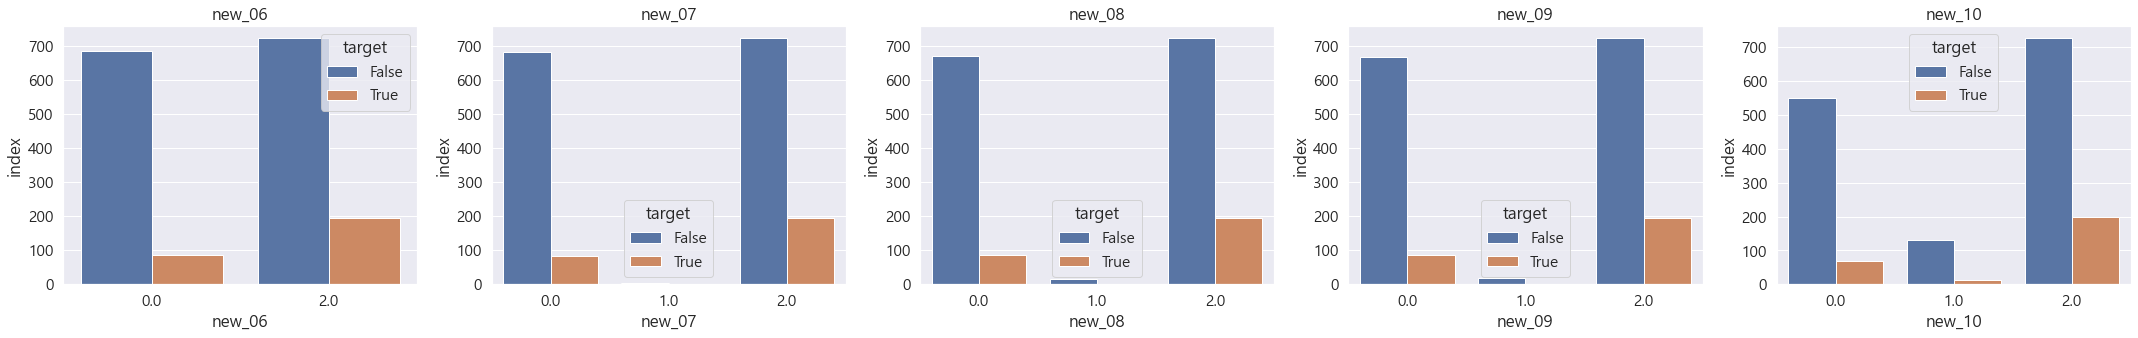

In [257]:
changes = ['new_01', 'new_02', 'new_03', 'new_04',
       'new_05', 'new_06', 'new_07', 'new_08', 'new_09', 'new_10']

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(30,5))

smallPlots(changes[0] , str(changes[0]), 0)
smallPlots(changes[1] , str(changes[1]), 1)
smallPlots(changes[2] , str(changes[2]), 2)
smallPlots(changes[3] , str(changes[3]), 3)
smallPlots(changes[4] , str(changes[4]), 4)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(30,5))

smallPlots(changes[5] , str(changes[5]), 0)
smallPlots(changes[6] , str(changes[6]), 1)
smallPlots(changes[7] , str(changes[7]), 2)
smallPlots(changes[8] , str(changes[8]), 3)
smallPlots(changes[9] , str(changes[9]), 4)

fig.tight_layout()
plt.show()

# 2. 훈련과 검증데이터

## 2.1. 현지실사 완료 데이터로 미방문 업소 예측
### 2.1.1. 현지실사가 완료된 데이터

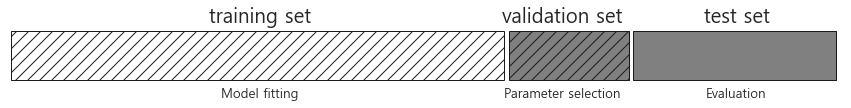

In [36]:
#! pip install mglearn
import mglearn
mglearn.plots.plot_threefold_split()

In [139]:
X
y

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,영업구분_2,영업구분_3,영업구분_4,영업구분_5,ARG_1,ARG_2,ARG_3,SEA_4,SEA_5,SEA_6
해외제조업소_코드,,,,,,,,,,,,,,,,,,,,,
CN000095375,True,True,True,True,True,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CN000010833,True,True,True,True,True,False,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VN000000420,True,True,True,True,True,True,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
JP000002818,True,True,True,True,True,True,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TH000001271,True,True,True,True,True,False,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000418,True,True,True,True,True,True,False,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
US000000318,True,True,True,True,True,True,True,True,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


해외제조업소_코드
CN000095375    False
CN000010833    False
VN000000420    False
JP000002818    False
TH000001271    False
               ...  
DE000000001    False
US000000418    False
US000000318    False
PH000000007    False
PH000000010    False
Name: target, Length: 1689, dtype: bool

In [142]:
original_X = X.copy()

### 2.1.2. 차원축소 with MCA

In [159]:
# 해외제조업소 대장_변경내역
vars_01 = ['new_01', 'new_02', 'new_03', 'new_04', 'new_05',
       'new_06', 'new_07', 'new_08', 'new_09', 'new_10', 'new_11', 'new_12',
       'new_13', 'new_14', 'new_15', 'new_16', 'new_17', 'new_42', 'modify_01',
       'modify_02', 'modify_03', 'modify_04', 'modify_05', 'modify_06',
       'modify_07', 'modify_08', 'modify_09', 'modify_10', 'modify_11',
       'modify_12', 'modify_13', 'modify_14', 'modify_15', 'modify_16',
       'modify_17', 'modify_42']

# 해외제조업소 품목
vars_02 =['기능성원료', '수입식품생성',
       '유통관리대상', '수산부산물', 'ANIMALMDCN', 'SEPARUSE', 'MIXTR', '신고구분_1',
       '신고구분_2', '신고구분_3', '신고구분_4', '신고구분_5', '신고구분_6', '신고구분_7', '신고구분_8',
       '품목_A', '품목_B', '품목_C', '품목_D', '품목_E', '품목_F', '품목_Z']

## 차원축소 1단계 : 해외제조업소 대장_변경내역

Text(0.5, 1.0, 'Correspondence analysis')

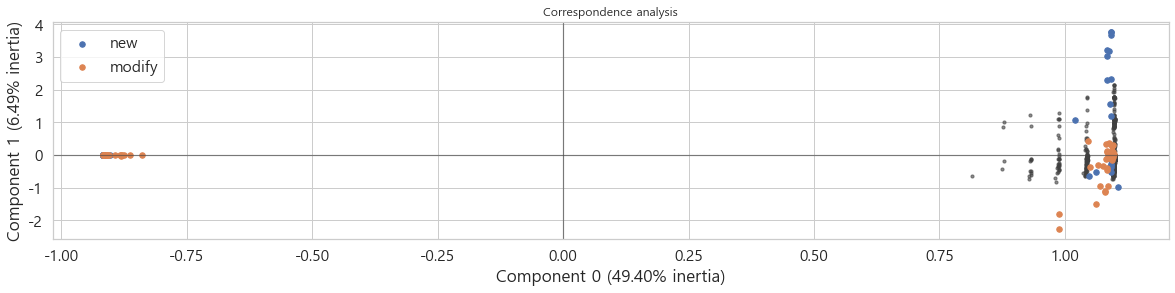

In [145]:
input_X_step01 = X[vars_01].copy()

mca_01 = prince.MCA(n_components=input_X_step01.shape[1]).fit(input_X_step01)
ax = mca_01.plot_coordinates(X = input_X_step01, figsize=(20, 4))#, show_column_labels=True)
ax.set_title("Correspondence analysis", fontsize = 12)

Text(0.5, 0, '주성분 개 수')

Text(0, 0.5, '총변동량 누적 설명 비율')

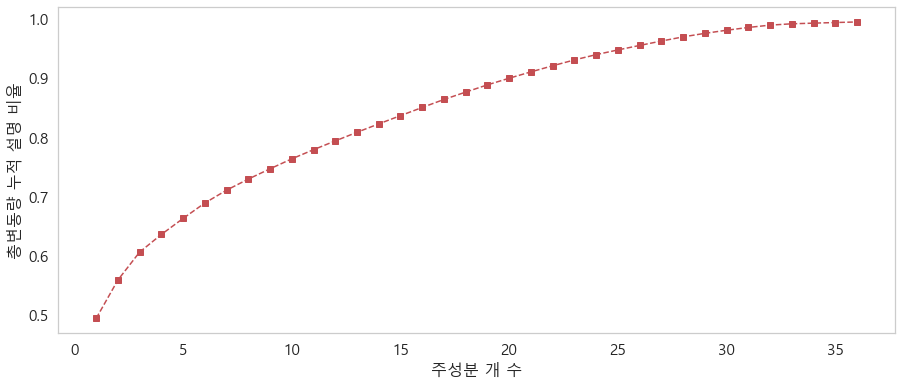

In [147]:
#mca.transform(input_X)
#mca.explained_inertia_[0:5]
plt.plot(np.arange(1, input_X_step01.shape[1]+1), np.cumsum(mca_01.explained_inertia_), 'rs--')
plt.xlabel('주성분 개 수', fontsize='16')
plt.ylabel('총변동량 누적 설명 비율', fontsize='16')

## 차원축소 2단계 : 해외제조업소 품목

Text(0.5, 1.0, 'Correspondence analysis')

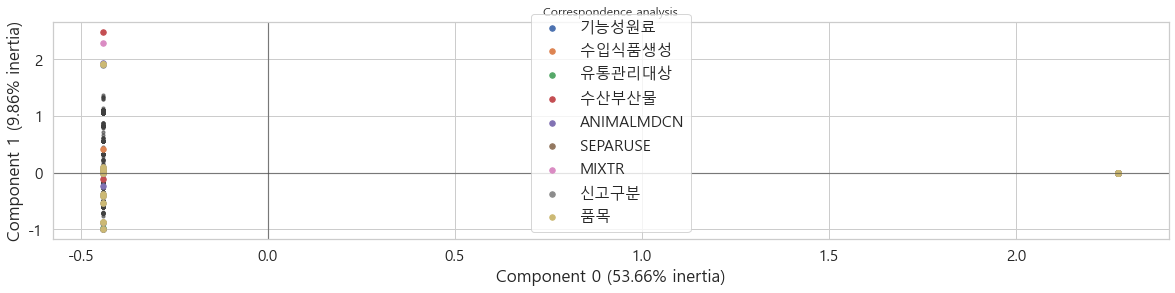

In [146]:
input_X_step02 = X[vars_02].copy()

mca_02 = prince.MCA(n_components=input_X_step02.shape[1]).fit(input_X_step02)
ax = mca_02.plot_coordinates(X = input_X_step02, figsize=(20, 4))#, show_column_labels=True)
ax.set_title("Correspondence analysis", fontsize = 12)

Text(0.5, 0, '주성분 개 수')

Text(0, 0.5, '총변동량 누적 설명 비율')

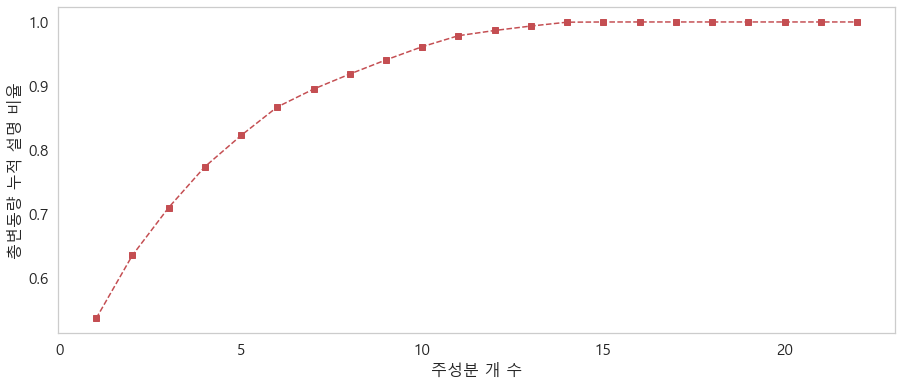

In [148]:
plt.plot(np.arange(1, input_X_step02.shape[1]+1), np.cumsum(mca_02.explained_inertia_), 'rs--')
plt.xlabel('주성분 개 수', fontsize='16')
plt.ylabel('총변동량 누적 설명 비율', fontsize='16')

## 2.2. 훈련과 검증, 테스트 데이터 구성

In [174]:
n_components = 5

X = original_X.copy()
input_X_step01 = X[vars_01].copy()
input_X_step02 = X[vars_02].copy()

mca_01_features = prince.MCA(n_components=n_components).fit_transform(input_X_step01)
mca_02_features = prince.MCA(n_components=n_components).fit_transform(input_X_step02)
X = pd.merge(X.drop(vars_01, axis=1), mca_01_features, left_index = True, right_index = True)
X = pd.merge(X.drop(vars_02, axis=1), mca_02_features, left_index = True, right_index = True)
X

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,0_x,1_x,2_x,3_x,4_x,0_y,1_y,2_y,3_y,4_y
CN000095375,True,True,True,True,True,False,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
CN000010833,True,True,True,True,True,False,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
VN000000420,True,True,True,True,True,True,True,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
JP000002818,True,True,True,True,True,True,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
TH000001271,True,True,True,True,True,False,True,True,True,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,2.272495,5.974820e-15,8.636016e-17,2.075400e-16,6.774257e-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DE000000001,True,True,True,True,True,True,False,True,True,False,...,0.988482,1.278806,0.515723,-0.562555,-0.498149,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
US000000418,True,True,True,True,True,True,False,True,True,False,...,1.099213,-0.148023,-0.443750,-0.088657,-0.131084,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
US000000318,True,True,True,True,True,True,True,True,True,False,...,1.097581,-0.505947,0.637271,-0.192334,0.097277,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
PH000000007,True,True,True,True,True,True,False,True,True,False,...,0.987709,1.091283,0.838967,-0.730807,-0.298126,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02


In [175]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y,  random_state=12)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.2, stratify=y_train, random_state=12)

print('훈련데이터(traing set) Data(X,y)크기와 부적합율')
[X_train.shape, y_train.shape]
(y_train.sum()/len(y_train)).round(4)
print('검증데이터(validation set) Data(X,y)크기와 부적합율')
[X_val.shape, y_val.shape]
(y_val.sum()/len(y_val)).round(4)
print('테스트데이터(test set) Data(X,y)크기와 부적합율')
[X_test.shape, y_test.shape]
(y_test.sum()/len(y_test)).round(4)

훈련데이터(traing set) Data(X,y)크기와 부적합율


[(1080, 49), (1080,)]

0.1667

검증데이터(validation set) Data(X,y)크기와 부적합율


[(271, 49), (271,)]

0.1661

테스트데이터(test set) Data(X,y)크기와 부적합율


[(338, 49), (338,)]

0.1657

### 실수형과 범주형 변수 정의

In [176]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features  = X.select_dtypes(include=['category']).columns
numeric_features
categorical_features

Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')

Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', '인증_1', '인증_2', '인증_3', '식품코드_1', '식품코드_2',
       '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2', '수산물코드_3',
       '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4', '영업구분_5',
       'ARG_1', 'ARG_2', 'ARG_3', 'SEA_4', 'SEA_5', 'SEA_6'],
      dtype='object')

## 2.1.2. Cross validation and Hyperparameter tuninig

In [357]:
from sklearn import ensemble 
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import SVC

classifiers = {}
classifiers.update({'Logistic regression': LogisticRegression()})
classifiers.update({'Ridge': RidgeClassifier()})

classifiers.update({'Decisiontree': DecisionTreeClassifier()})
classifiers.update({'Extra Trees': ExtraTreeClassifier()})
classifiers.update({'Random Forest': ensemble.RandomForestClassifier()})
classifiers.update({'Gradient Boosting': ensemble.GradientBoostingClassifier()})

classifiers.update({'SVC': SVC(random_state=11, max_iter=300, probability=True)})

classifiers

{'Logistic regression': LogisticRegression(),
 'Ridge': RidgeClassifier(),
 'Decisiontree': DecisionTreeClassifier(),
 'Extra Trees': ExtraTreeClassifier(),
 'Random Forest': RandomForestClassifier(),
 'Gradient Boosting': GradientBoostingClassifier(),
 'SVC': SVC(max_iter=300, probability=True, random_state=11)}

In [358]:
DECISION_FUNCTIONS = {'SVC', 'Ridge'}

In [359]:
parameters = {}

parameters.update({'Logistic regression': 
{
'classifier__C': np.logspace(-4, 4, 20), 
'classifier__class_weight': [None, 'balanced'],
'classifier__penalty': ['l1', 'l2']    
}})

parameters.update({'Ridge': 
{ 
'classifier__alpha': [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.25, 0.50, 0.75, 1.0]
}})

parameters.update({'Decisiontree': 
{ 
'classifier__criterion' :['gini', 'entropy'],
'classifier__splitter': ['best', 'random'],
'classifier__class_weight': [None, 'balanced'],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__max_depth' : [1,2,3, 4, 5, 6, 7, 8],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
}})

parameters.update({'Extra Trees': 
{ 
'classifier__criterion' :['gini', 'entropy'],
'classifier__splitter': ['best', 'random'],
'classifier__class_weight': [None, 'balanced'],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__max_depth' : [1,2,3, 4, 5, 6, 7, 8],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
}})


parameters.update({'Random Forest': 
{ 
'classifier__n_estimators': [50, 100, 150, 200, 250, 300],
'classifier__class_weight': [None, 'balanced'],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__max_depth' : [int(x) for x in np.linspace(3, 50, 20)],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__criterion' :['gini', 'entropy'],
'classifier__n_jobs': [-1]
}})

parameters.update({'Gradient Boosting': 
{ 
'classifier__learning_rate':[0.15,0.1,0.05,0.01,0.005,0.001], 
'classifier__n_estimators': [200],
'classifier__max_depth': [2,3,4,5,6],
'classifier__min_samples_split': [0.005, 0.01, 0.05, 0.10],
'classifier__min_samples_leaf': [0.005, 0.01, 0.05, 0.10],
'classifier__max_features': ['auto', 'sqrt', 'log2'],
'classifier__subsample': [0.8, 0.9, 1]
}})

parameters.update({'SVC': 
{ 
'classifier__kernel': ['linear', 'rbf', 'poly'],
'classifier__gamma': ['auto'],
'classifier__C': [0.1, 0.5, 1, 5, 10, 50, 100],
'classifier__degree': [1, 2, 3, 4, 5, 6]
}})

In [360]:
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, plot_roc_curve, plot_confusion_matrix, classification_report, balanced_accuracy_score
from sklearn import metrics

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

from joblib import dump, load

In [366]:
results = {}
kf = KFold(n_splits=5)

for classifier_label, classifier in classifiers.items():
    
    # 1. 입력변수의 유형에 따라 데이터 전처리를 tranformers로 저장
    numeric_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())])
    categorical_transformer = Pipeline(steps=[
        #('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('woe_catencoder', ce.woe.WOEEncoder())])
    
    # 2. tranformers를 ColumnTransformer로 연결
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)])    
    
    # 3. 데이터전처리를 파이프라인으로 연결
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)])
    
    # 4. 랜덤그리드 서치로 파이프라인(데이터존처리와 알고리즘), 하이퍼파라미터, 교차검증, 최적화 metric) 연결
    param_grid = parameters[classifier_label]
    grid = RandomizedSearchCV(pipeline, param_grid, cv = kf,  n_jobs= -1,
                          n_iter = 30,
                          verbose=1,
                          scoring = 'recall_macro')  # recall_macro
    
    # 5. 훈련데이터로 최적 모델 찾고 저장하기
    grid.fit(X_train, y_train) # Fitting 
    
    print('최적 모델의 훈련데이터 score: {:.3f}'.format(grid.best_score_))
    print('최적모델의 검증데이터 score: {:.3f}'.format(grid.score(X_val, y_val)))
    #print('최적 모델 parameter: {}'.format(grid.best_params_))
    
    dump(grid.best_estimator_, path + '/' + classifier_label + '.joblib')
    
    # 6. 훈련과정 보기
    #pd.DataFrame(grid.cv_results_).sort_values('rank_test_score').head()
    
    # 6. 훈련데이터로 재현율로 최적화된 모형으로 검증데이터에 적용 
    y_pred = grid.best_estimator_.predict(X_val)
    
    #################################################
    if classifier_label in DECISION_FUNCTIONS:
        y_proba = grid.decision_function(X_val)
        y_score = y_proba
        bs = 'NA'
    else:
        y_proba = grid.predict_proba(X_val)[:,1]
        y_score = y_proba
        bs = metrics.brier_score_loss(y_val, y_proba)
    ##################################################
    
    
    #y_proba = grid.best_estimator_.predict_proba(X_val)
    #y_score = y_proba[:,1]
    
    print('*'*100); print('Classifier name : ', classifier_label )
    print(classification_report(y_val, y_pred))

    result = {#'Classifier': classifier_label,
              #'Best Parameters': grid.best_params_,
              'Recall_macro': metrics.recall_score(y_val, y_pred, average='macro'),
              'AUROC' : metrics.roc_auc_score(y_val, y_score),
              'Average PR': metrics.average_precision_score(y_val, y_score),
              'F1-score': metrics.f1_score(y_val, y_pred),
              'Accuracy': metrics.accuracy_score(y_val, y_pred),
              'Log_loss': metrics.log_loss(y_val, y_proba),
              'Brier_scor': bs,   # Ridge와 SVC는 1보다 크게나옴
              'MC': metrics.matthews_corrcoef(y_val, y_pred),
              'KC': metrics.cohen_kappa_score(y_val, y_pred),
              'Ballanced Accuracy' : balanced_accuracy_score(y_val, y_pred)
             }
    results.update({classifier_label: result})

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__penalty': ['l1', 'l2']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.818
최적모델의 검증데이터 score: 0.789


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Logistic regression.joblib']

****************************************************************************************************
Classifier name :  Logistic regression
              precision    recall  f1-score   support

       False       0.94      0.87      0.90       226
        True       0.52      0.71      0.60        45

    accuracy                           0.84       271
   macro avg       0.73      0.79      0.75       271
weighted avg       0.87      0.84      0.85       271

Fitting 5 folds for each of 11 candidates, totalling 55 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
       '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2', '수산물코드_3',
       '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4', '영업구분_5',
       'ARG_1', 'ARG_2', 'ARG_3', 'SEA_4', 'SEA_5', 'SEA_6'],
      dtype='object'))])),
                                             ('classifier',
                                              RidgeClassifier())]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__alpha': [1e-07, 1e-06,
                                                              1e-05, 0.0001,
                                                              0.001, 0.01, 0.1,
                                                              0.25, 0.5, 0.75,
                                                              1.0]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.780
최적모델의 검증데이터 score: 0.747


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Ridge.joblib']

****************************************************************************************************
Classifier name :  Ridge
              precision    recall  f1-score   support

       False       0.91      0.96      0.94       226
        True       0.73      0.53      0.62        45

    accuracy                           0.89       271
   macro avg       0.82      0.75      0.78       271
weighted avg       0.88      0.89      0.88       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [1, 2, 3, 4, 5,
                                                                  6, 7, 8],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__splitter': ['best',
                                                                 'random']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.786
최적모델의 검증데이터 score: 0.796


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Decisiontree.joblib']

****************************************************************************************************
Classifier name :  Decisiontree
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       226
        True       0.80      0.62      0.70        45

    accuracy                           0.91       271
   macro avg       0.86      0.80      0.82       271
weighted avg       0.91      0.91      0.91       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced'],
                                        'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [1, 2, 3, 4, 5,
                                                                  6, 7, 8],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__splitter': ['best',
                                                                 'random']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.809
최적모델의 검증데이터 score: 0.771


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Extra Trees.joblib']

****************************************************************************************************
Classifier name :  Extra Trees
              precision    recall  f1-score   support

       False       0.93      0.90      0.91       226
        True       0.56      0.64      0.60        45

    accuracy                           0.86       271
   macro avg       0.74      0.77      0.76       271
weighted avg       0.87      0.86      0.86       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
                                        'classifier__max_depth': [3, 5, 7, 10,
                                                                  12, 15, 17,
                                                                  20, 22, 25,
                                                                  27, 30, 32,
                                                                  35, 37, 40,
                                                                  42, 45, 47,
                                                                  50],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [50, 100,
                                                                     150, 200,
                                                                     250, 300],
                                        'classifier__n_jobs': [-1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.828
최적모델의 검증데이터 score: 0.840


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Random Forest.joblib']

****************************************************************************************************
Classifier name :  Random Forest
              precision    recall  f1-score   support

       False       0.95      0.92      0.94       226
        True       0.67      0.76      0.71        45

    accuracy                           0.90       271
   macro avg       0.81      0.84      0.82       271
weighted avg       0.90      0.90      0.90       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
                   param_distributions={'classifier__learning_rate': [0.15, 0.1,
                                                                      0.05,
                                                                      0.01,
                                                                      0.005,
                                                                      0.001],
                                        'classifier__max_depth': [2, 3, 4, 5,
                                                                  6],
                                        'classifier__max_features': ['auto',
                                                                     'sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [0.005,
                                                                         0.01,
                                                                         0.05,
                                                                         0.1],
                                        'classifier__min_samples_split': [0.005,
                                                                          0.01,
                                                                          0.05,
                                                                          0.1],
                                        'classifier__n_estimators': [200],
                                        'classifier__subsample': [0.8, 0.9, 1]},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.810
최적모델의 검증데이터 score: 0.833


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/Gradient Boosting.joblib']

****************************************************************************************************
Classifier name :  Gradient Boosting
              precision    recall  f1-score   support

       False       0.94      0.98      0.96       226
        True       0.86      0.69      0.77        45

    accuracy                           0.93       271
   macro avg       0.90      0.83      0.86       271
weighted avg       0.93      0.93      0.93       271

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                MinMaxScaler())]),
                                                                               Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('woe_catencoder',
                                                                                                WOEEncoder())]),
                                                                               Index(['업소명...
       'ARG_1', 'ARG_2', 'ARG_3', 'SEA_4', 'SEA_5', 'SEA_6'],
      dtype='object'))])),
                                             ('classifier',
                                              SVC(max_iter=300,
                                                  probability=True,
                                                  random_state=11))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'classifier__C': [0.1, 0.5, 1, 5, 10,
                                                          50, 100],
                                        'classifier__degree': [1, 2, 3, 4, 5,
                                                               6],
                                        'classifier__gamma': ['auto'],
                                        'classifier__kernel': ['linear', 'rbf',
                                                               'poly']},
                   scoring='recall_macro', verbose=1)

최적 모델의 훈련데이터 score: 0.810
최적모델의 검증데이터 score: 0.793


['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml/SVC.joblib']

****************************************************************************************************
Classifier name :  SVC
              precision    recall  f1-score   support

       False       0.93      0.96      0.95       226
        True       0.78      0.62      0.69        45

    accuracy                           0.91       271
   macro avg       0.85      0.79      0.82       271
weighted avg       0.90      0.91      0.90       271



# 3. 모델 평가 및 선택

In [367]:
pd.set_option("display.precision", 2)
pd.DataFrame(results).T

,Recall_macro,AUROC,Average PR,F1-score,Accuracy,Log_loss,Brier_scor,MC,KC,Ballanced Accuracy
Logistic regression,0.79,0.9,0.71,0.6,0.84,0.4,0.12,0.51,0.5,0.79
Ridge,0.75,0.88,0.71,0.62,0.89,2.77,NA,0.56,0.55,0.75
Decisiontree,0.8,0.91,0.79,0.7,0.91,0.23,0.07,0.66,0.65,0.8
Extra Trees,0.77,0.84,0.62,0.6,0.86,0.44,0.14,0.51,0.51,0.77
Random Forest,0.84,0.93,0.79,0.71,0.9,0.35,0.1,0.65,0.65,0.84
Gradient Boosting,0.83,0.94,0.83,0.77,0.93,0.21,0.06,0.73,0.72,0.83
SVC,0.79,0.89,0.78,0.69,0.91,2.36,NA,0.64,0.64,0.79


## CALIBRATION CURVE

  0%|          | 0/7 [00:00<?, ?it/s]

<AxesSubplot:title={'center':'Calibration plots (Reliability Curves)'}, xlabel='Mean predicted value', ylabel='Fraction of positives'>

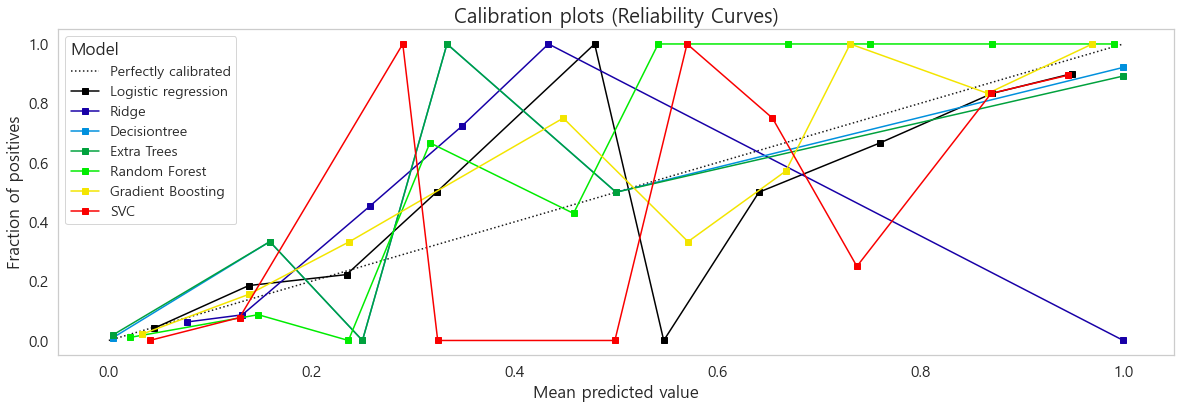

In [372]:
from tqdm import tqdm_notebook
import scikitplot as skplt

classifier_labels = []
probas_list = []
for classifier_label, classifier in tqdm_notebook(classifiers.items()):
    
    ##################################################################
    if classifier_label in DECISION_FUNCTIONS:
        y_proba = classifier.fit(X_train, y_train).decision_function(X_val)
    else:
        y_proba = classifier.fit(X_train, y_train).predict_proba(X_val)
    ##################################################################    
    #y_proba = classifier.fit(X_train, y_train).predict_proba(X_val)
       
    probas_list.append(y_proba)
    classifier_labels.append(classifier_label)

skplt.metrics.plot_calibration_curve(y_val, probas_list, classifier_labels, figsize=(20,6))
leg = plt.legend(title='Model', fontsize = 14)
leg._legend_box.align = 'left'

## 테스트데이터(X_test)에 적용하여 결과 확인 : BMT

In [373]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score
# 성능지표
from sklearn.metrics import accuracy_score, plot_roc_curve 
from sklearn.metrics import plot_confusion_matrix, classification_report

import glob
glob.glob(path + '/*.*job*')

['D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Decisiontree.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Extra Trees.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Gradient Boosting.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Logistic regression.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Random Forest.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\Ridge.joblib',
 'D:\\smart food\\현지실사\\2022_2_현지실사\\working_ml\\SVC.joblib']

## 랜덤포레스트 최적 모델 불러오기

In [375]:
rf = load(glob.glob(path + '/*.*job*')[2])
rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', '인증_1',...
       '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2', '수산물코드_3',
       '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4', '영업구분_5',
       'ARG_1', 'ARG_2', 'ARG_3', 'SEA_4', 'SEA_5', 'SEA_6'],
      dtype='object'))])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            max_features='auto',
                                            min_samples_leaf=0.005,
                                            min_samples_split=0.05,
                                            n_estimators=200, subsample=0.9))])

In [376]:
rf.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  Index(['0_x', '1_x', '2_x', '3_x', '4_x', '0_y', '1_y', '2_y', '3_y', '4_y'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('woe_catencoder',
                                                                   WOEEncoder())]),
                                                  Index(['업소명', '대표자성명', '주소', '전화번호', '이메일', '회사이메일', '팩스', '인증', '공식인증', '수산물',
       'N', 'R', 'S', 'Y', '인증_1',...
       '식품코드_3', '식품코드_4', '식품코드_5', '식품코드_6', '수산물코드_1', '수산물코드_2', '수산물코드_3',
       '중단해제', '중단중', '영업구분_1', '영업구분_2', '영업구분_3', '영업구분_4', '영업구분_5',
       'ARG_1', 'A

0.9260355029585798

              precision    recall  f1-score   support

       False       0.94      0.98      0.96       282
        True       0.84      0.68      0.75        56

    accuracy                           0.93       338
   macro avg       0.89      0.83      0.85       338
weighted avg       0.92      0.93      0.92       338



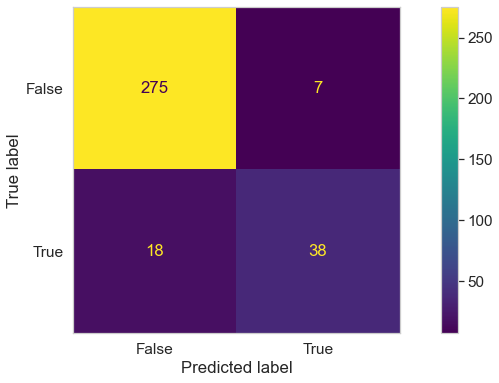

In [377]:
y_predict = rf.fit(X_train, y_train).predict(X_test)
accuracy_score(y_test, y_predict)
print(classification_report(y_test, y_predict))
sns.set_style("whitegrid", {'axes.grid' : False})
plot_confusion_matrix(rf, X_test, y_test)

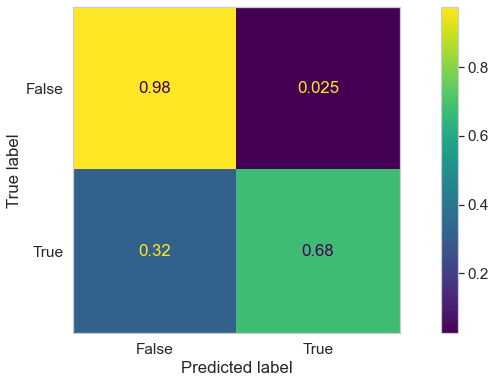

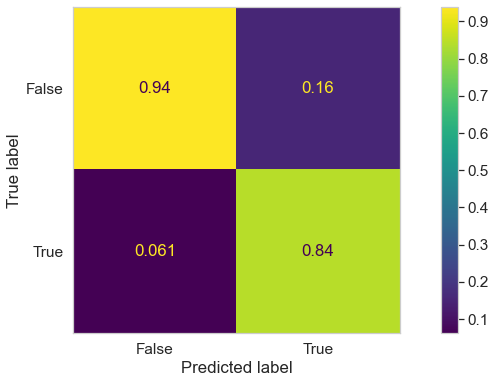

In [378]:
plot_confusion_matrix(rf, X_test, y_test, normalize='true')
plot_confusion_matrix(rf, X_test, y_test, normalize='pred')

## 비모수통계방식의 무작위성

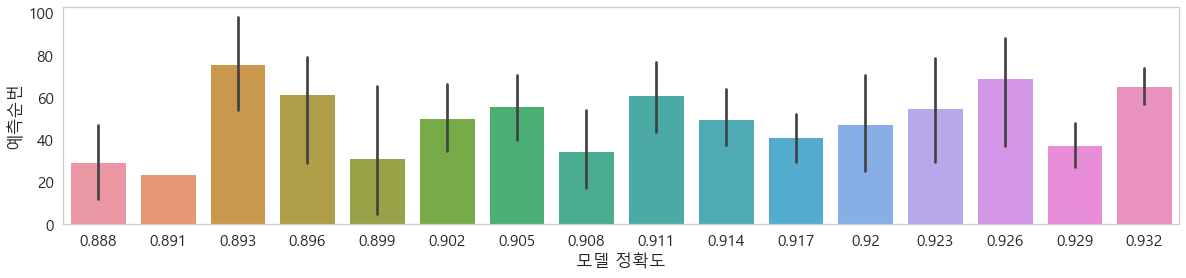

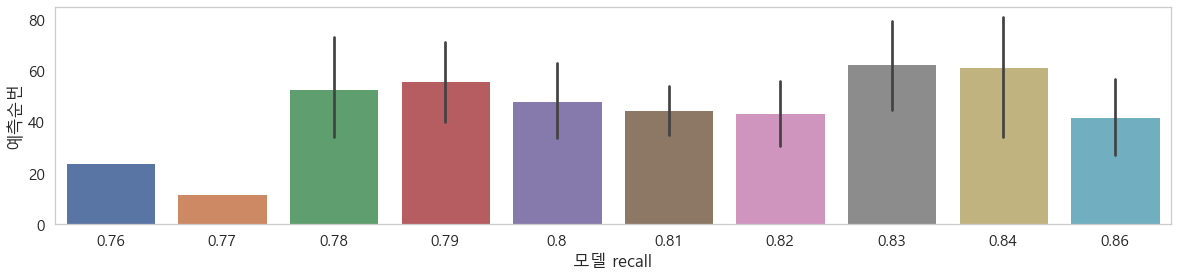

In [392]:
plt.rcParams['font.family']='Malgun Gothic' # 한글폰트

acc_list = []
recall_list = []

for i in np.random.choice(2500, 100, replace=False) :
    clf = ensemble.RandomForestClassifier(n_estimators = 5, random_state = i) 
    preds =  clf.fit(X_train, y_train).predict(X_test)  
    acc = round(accuracy_score(y_true = y_test, y_pred = preds), 3)
    recall = metrics.recall_score(y_true = y_test, y_pred = preds, average='macro')
    
    acc_list.append(acc)
    recall_list.append(recall)

data = (pd.Series(acc_list).reset_index().
        rename(columns={'index': '예측순번', 0: '모델 정확도'}))
fig, ax = plt.subplots()
fig.set_size_inches(20, 4)
ax = sns.barplot(x='모델 정확도', y='예측순번', data=data)
plt.show()


data = (pd.Series(recall_list).reset_index().
        rename(columns={'index': '예측순번', 0: '모델 recall'})).round(2)
fig, ax = plt.subplots()
fig.set_size_inches(20, 4)
ax = sns.barplot(x='모델 recall', y='예측순번', data=data)

## Decile 별로 부적합건수
- '1'은 부적합판정이 높은 percentile

array([[<AxesSubplot:title={'center':'probability_y'}>]], dtype=object)

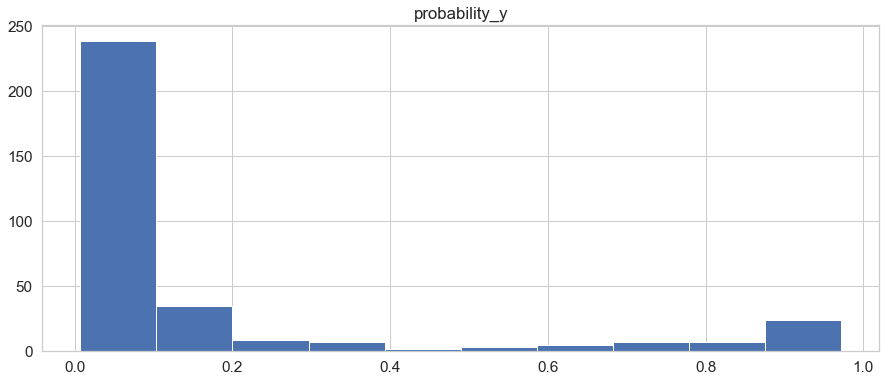

In [379]:
y_proba = rf.fit(X_train, y_train).predict_proba(X_test)
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf.hist()

Counter({False: 235, True: 36})

Text(0.5, 1.0, 'Distribution of probability of positive')

Text(0.5, 0, 'probability of positive')

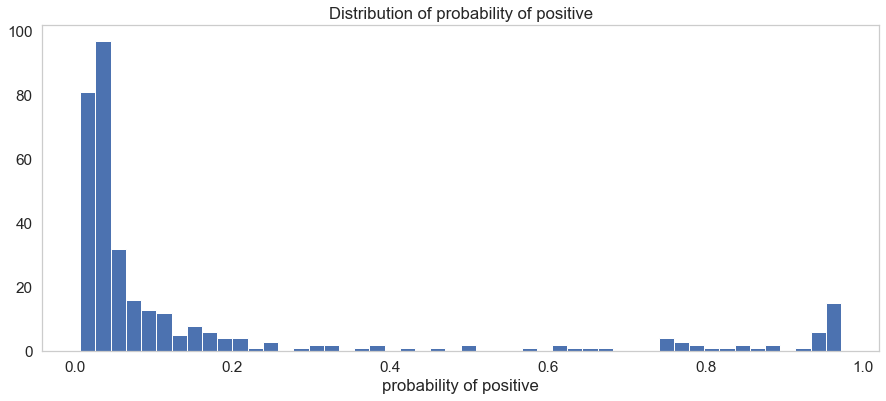

In [380]:
from collections import Counter
Counter(y_pred)
ax = plt.hist(y_proba[:, 1], bins=50)
plt.title('Distribution of probability of positive'); plt.xlabel('probability of positive')

In [381]:
tf['probability_y'].value_counts()

1.27e-02    12
3.97e-02    10
3.76e-02     7
1.30e-02     7
9.94e-02     4
            ..
7.78e-02     1
7.70e-02     1
7.58e-02     1
7.51e-02     1
6.94e-03     1
Name: probability_y, Length: 285, dtype: int64

<Figure size 720x360 with 0 Axes>

<AxesSubplot:xlabel='decile', ylabel='actual_y'>

Text(0.5, 1.0, 'Profit brought by each product decile')

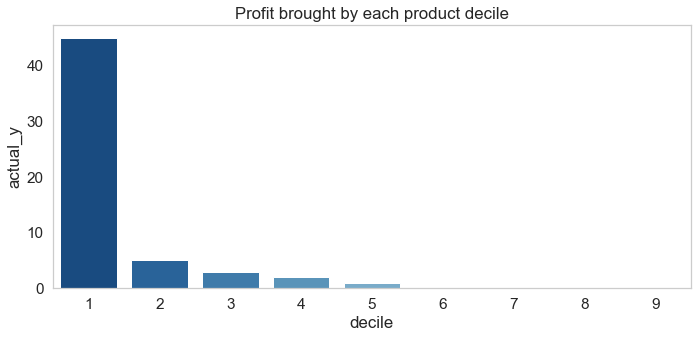

In [382]:
tf = pd.DataFrame({'actual_y' : y_test, 'probability_y' : y_proba[:, 1]}).sort_values('probability_y', ascending=False)
tf['decile'] = pd.qcut(tf["probability_y"], q = 5, labels = list(range(5, 0, -1)))

data = tf[['actual_y', 'decile']].groupby("decile").sum().reset_index().sort_values('decile', ascending=False)
plt.figure(figsize = (10,5))
sns.barplot(x = 'decile', y = 'actual_y', data = data, order = range(1, 10), palette = 'Blues_r')
plt.title("Profit brought by each product decile")
plt.tight_layout()

<AxesSubplot:title={'center':'Lift Curve'}, xlabel='Percentage of sample', ylabel='Lift'>

<AxesSubplot:title={'center':'Cumulative Gains Curve'}, xlabel='Percentage of sample', ylabel='Gain'>

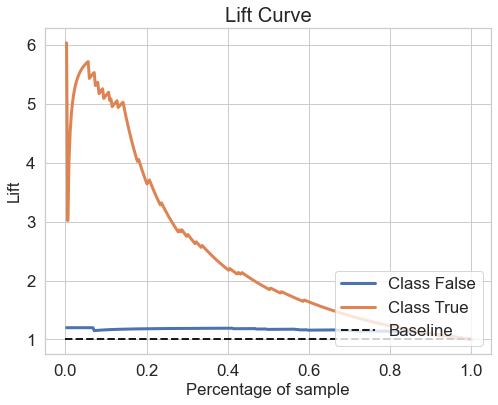

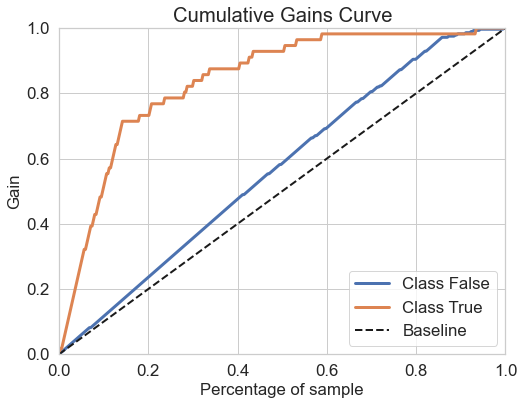

In [270]:
plt.rcParams["figure.figsize"] = (8,6)
y_proba = rf.predict_proba(X_test)
skplt.metrics.plot_lift_curve(y_test, y_proba)
skplt.metrics.plot_cumulative_gain(y_test, y_proba)

<AxesSubplot:title={'center':'KS Statistic Plot'}, xlabel='Threshold', ylabel='Percentage below threshold'>

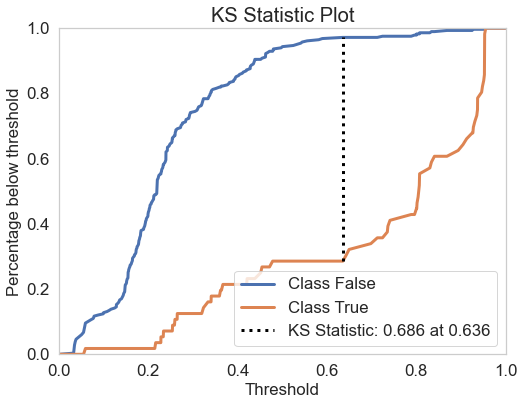

In [271]:
skplt.metrics.plot_ks_statistic(y_test, y_proba)

<AxesSubplot:title={'center':'ROC Curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

<AxesSubplot:title={'center':'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>

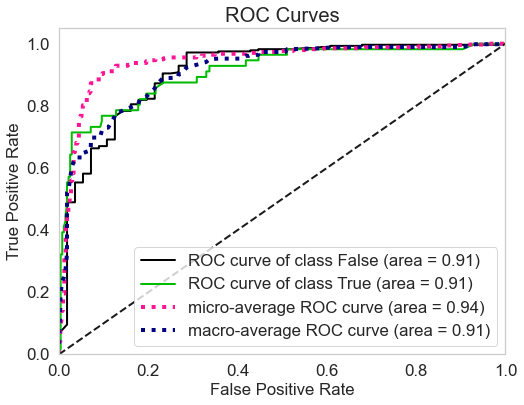

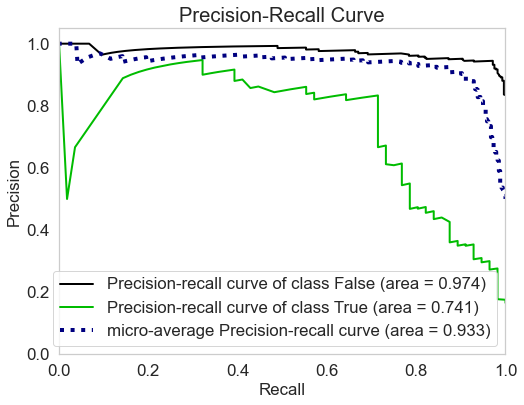

In [272]:
skplt.metrics.plot_roc(y_test, y_proba)
skplt.metrics.plot_precision_recall(y_test, y_proba)

In [273]:
from sklearn.metrics import precision_recall_curve
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')
p, r, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

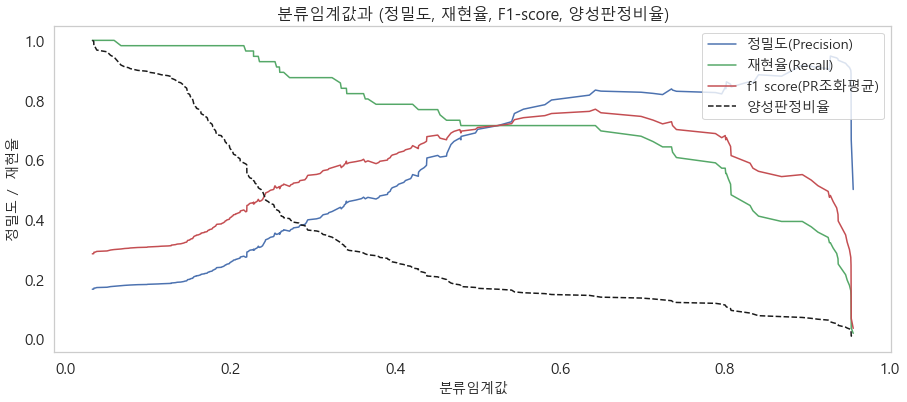

In [274]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds): 
    plt.rcParams["figure.figsize"] = (15,6)
    plt.rcParams['font.family']='Malgun Gothic' # 한글폰트
    plt.title('분류임계값과 (정밀도, 재현율, F1-score, 양성판정비율)', fontsize='16') 
    plt.plot(thresholds, precisions[:-1], 'b-', label='정밀도(Precision)') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='재현율(Recall)') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]), 
             'r-', label='f1 score(PR조화평균)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='양성판정비율') # q-ratio
    plt.ylabel('정밀도 /  재현율', fontsize='14') 
    plt.xlabel('분류임계값', fontsize='14') 
    plt.legend(loc='best', fontsize='14') 
plot_precision_recall_vs_threshold(p, r, thresholds)

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

<AxesSubplot:title={'center':'Learning Curve'}, xlabel='Training examples', ylabel='Score'>

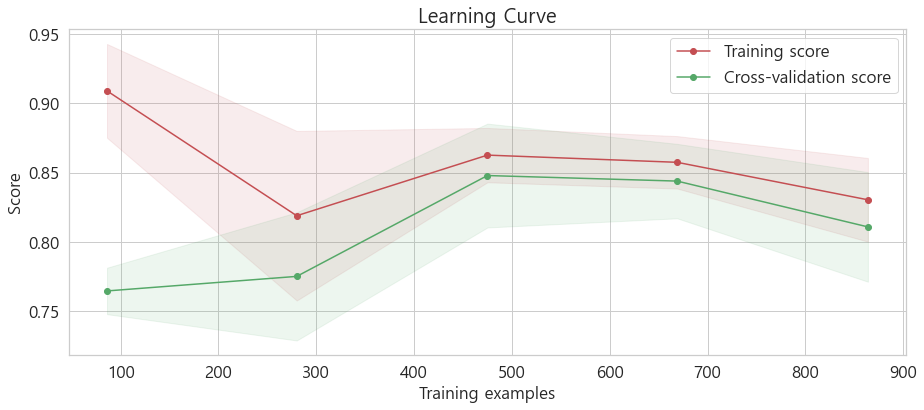

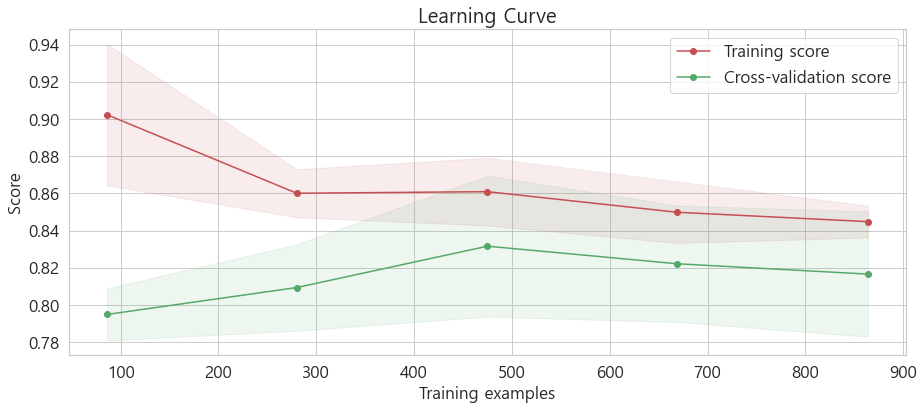

In [275]:
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='precision_macro')
skplt.estimators.plot_learning_curve(rf, X_train, y_train, scoring='recall_macro')

(array([41., 99., 78., 34., 28.,  8.,  4.,  6., 15., 25.]),
 array([0.03240656, 0.12472745, 0.21704835, 0.30936925, 0.40169015,
        0.49401104, 0.58633194, 0.67865284, 0.77097374, 0.86329464,
        0.95561553]),
 <BarContainer object of 10 artists>)

(array([25., 15.,  6.,  4.,  8., 28., 34., 78., 99., 41.]),
 array([0.04438447, 0.13670536, 0.22902626, 0.32134716, 0.41366806,
        0.50598896, 0.59830985, 0.69063075, 0.78295165, 0.87527255,
        0.96759344]),
 <BarContainer object of 10 artists>)

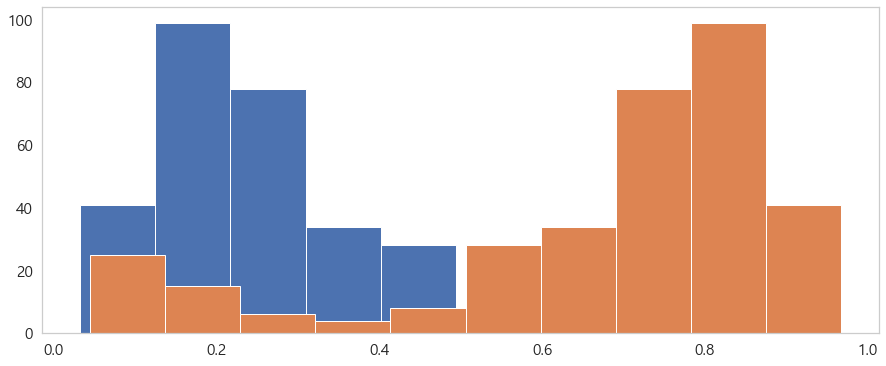

In [276]:
plt.hist(y_proba[:, 1]) 
plt.hist(y_proba[:, 0]) 

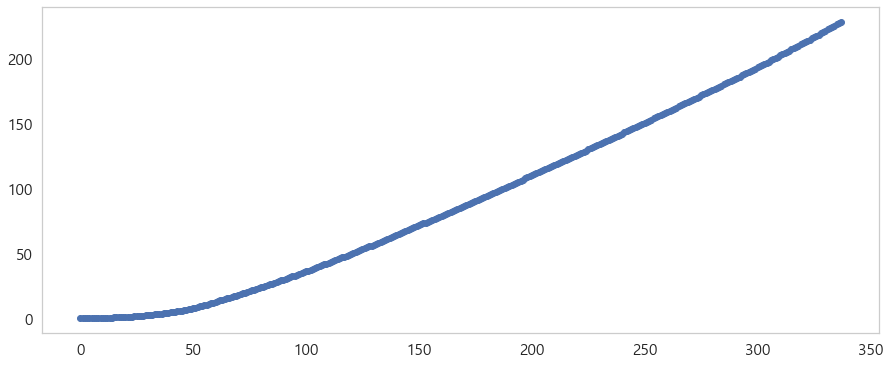

In [277]:
plt.scatter(np.arange(len(y_proba[:, 0])), np.sort(y_proba[:, 0]).cumsum()) 

In [278]:
from sklearn.metrics import balanced_accuracy_score, recall_score, precision_score

acc_list = []
recall_list = []
precision_list= []

for i in np.random.choice(2500, 300, replace=False) :
    clf = ensemble.RandomForestClassifier(n_estimators = 30, random_state = i) 
    preds =  clf.fit(X_train, y_train).predict(X_val) 
    
    bal_acc = round(balanced_accuracy_score(y_true = y_val, y_pred = preds), 3)
    recall = round(recall_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    precision = round(precision_score(y_true= y_val, y_pred  = preds, average='macro'), 3)
    
    acc_list.append(bal_acc)
    recall_list.append(recall)
    precision_list.append(precision)

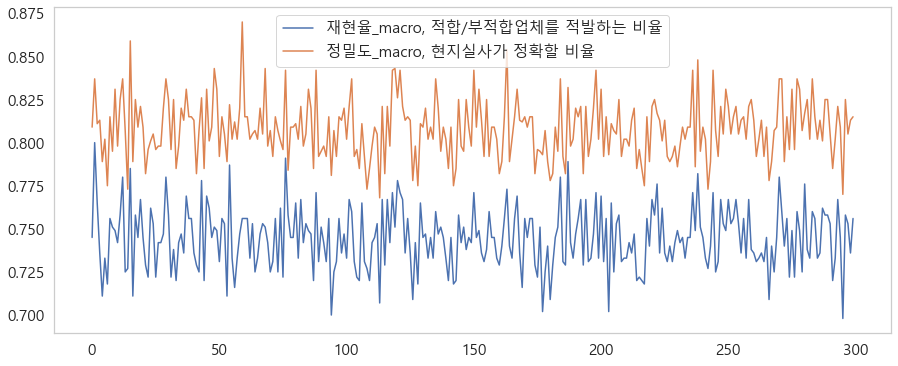

In [279]:
plt.plot(recall_list, label='재현율_macro, 적합/부적합업체를 적발하는 비율')
plt.plot(precision_list, label='정밀도_macro, 현지실사가 정확할 비율')
plt.legend()

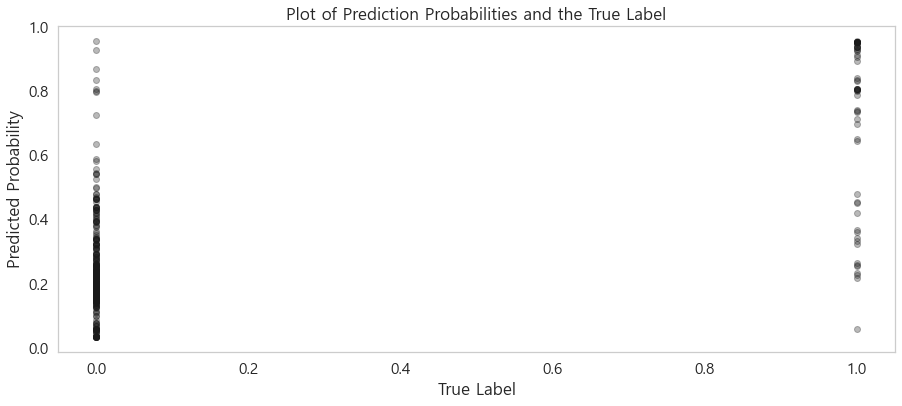

In [280]:
data = pd.DataFrame(np.c_[y_proba[:,1], y_test], columns=['Predicted Probability','True Label'])

ax = sns.regplot(x="True Label", y="Predicted Probability", color='k', 
                 fit_reg=False, scatter_kws={'alpha':0.3},
                 data=data).set_title('Plot of Prediction Probabilities and the True Label')

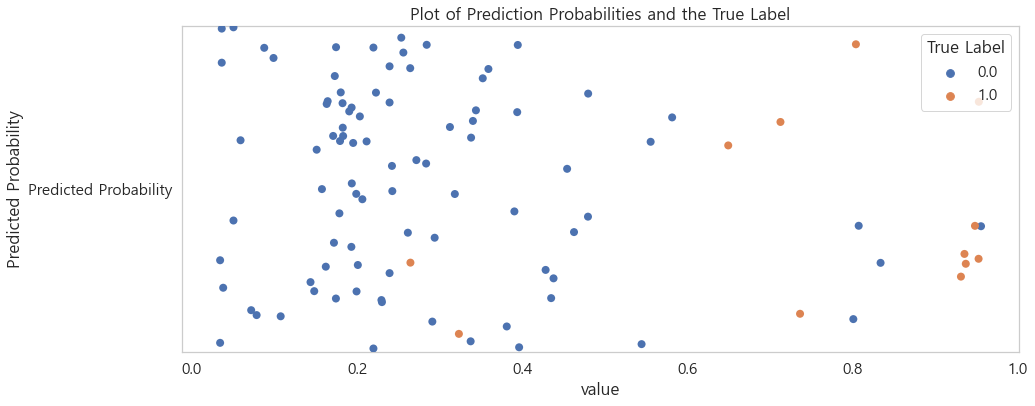

In [286]:
datamelted = pd.melt(data, "True Label", var_name="Predicted Probability")
ax = sns.stripplot(x="value", y="Predicted Probability",
                   hue='True Label', jitter=0.5, size= 8,
                   data=datamelted.sample(100, random_state=13)).set_title('Plot of Prediction Probabilities and the True Label')

RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)

<Figure size 1800x360 with 0 Axes>

Text(0, 0.5, 'Features Importance')

Text(0.5, 1.0, '변수 중요도')

([<matplotlib.axis.XTick at 0x21c803079a0>,
 [Text(0, 0, '업소명'),
  Text(1, 0, '대표자성명'),
  Text(2, 0, '주소'),
  Text(3, 0, '전화번호'),
  Text(4, 0, '이메일'),
  Text(5, 0, '회사이메일'),
  Text(6, 0, '팩스'),
  Text(7, 0, '인증'),
  Text(8, 0, '공식인증'),
  Text(9, 0, '수산물'),
  Text(10, 0, 'N'),
  Text(11, 0, 'R'),
  Text(12, 0, 'S'),
  Text(13, 0, 'Y'),
  Text(14, 0, '인증_1'),
  Text(15, 0, '인증_2'),
  Text(16, 0, '인증_3'),
  Text(17, 0, '식품코드_1'),
  Text(18, 0, '식품코드_2'),
  Text(19, 0, '식품코드_3'),
  Text(20, 0, '식품코드_4'),
  Text(21, 0, '식품코드_5'),
  Text(22, 0, '식품코드_6'),
  Text(23, 0, '수산물코드_1'),
  Text(24, 0, '수산물코드_2'),
  Text(25, 0, '수산물코드_3'),
  Text(26, 0, '중단해제'),
  Text(27, 0, '중단중'),
  Text(28, 0, '영업구분_1'),
  Text(29, 0, '영업구분_2'),
  Text(30, 0, '영업구분_3'),
  Text(31, 0, '영업구분_4'),
  Text(32, 0, '영업구분_5'),
  Text(33, 0, 'ARG_1'),
  Text(34, 0, 'ARG_2'),
  Text(35, 0, 'ARG_3'),
  Text(36, 0, 'SEA_4'),
  Text(37, 0, 'SEA_5'),
  Text(38, 0, 'SEA_6'),
  Text(39, 0, '0_x'),
  Text(40, 0, '1_x'),
  Text(4

<BarContainer object of 49 artists>

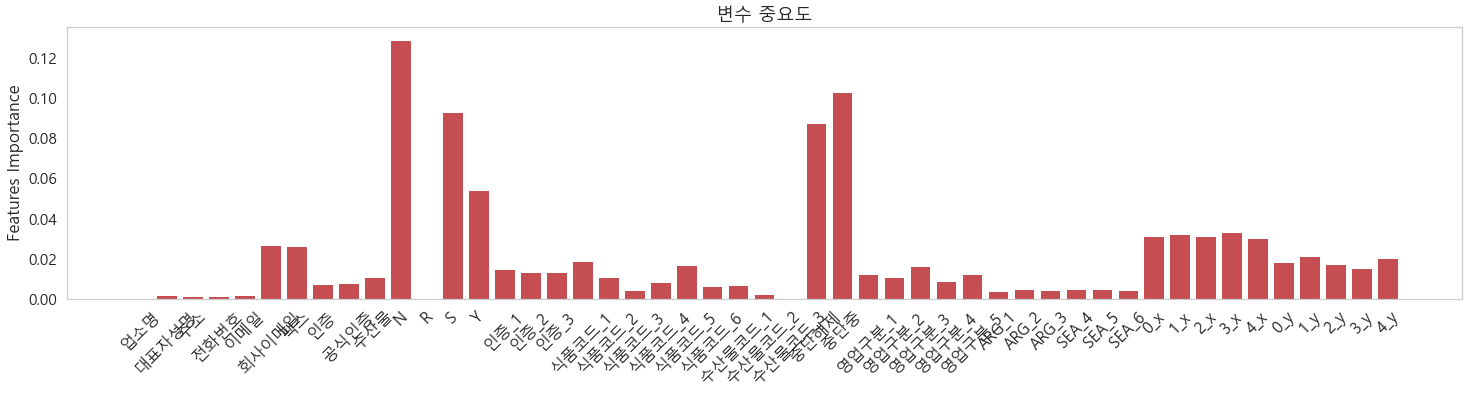

In [287]:
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, 
                                                  stratify= y, random_state=11)
dt = ensemble.RandomForestClassifier(n_estimators=300, oob_score=True, random_state=1357)
dt.fit(X, y)
plt.figure(figsize=(25,5)); plt.ylabel('Features Importance')
plt.title('변수 중요도', fontsize=18)
plt.xticks(np.arange(X.shape[1]), X.columns, rotation='45', fontsize=16)
plt.bar(range(X.shape[1]), dt.feature_importances_, color='r')

## 로지스틱회귀모형으로 해석

In [288]:
model = LogisticRegression(solver='saga', random_state=11)
params = {'C': np.logspace(-4, 4, 20), 'penalty': ['l1', 'l2']}
grid = RandomizedSearchCV(model, param_distributions=params, cv=kf,
                          scoring = 'recall')
grid.fit(X_train, y_train)
print('optimal train score: {:.3f}'.format(grid.best_score_))
print('test score: {:.3f}'.format(grid.score(X_test, y_test)))
print('optimal parameter: {}'.format(grid.best_params_))

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
                   estimator=LogisticRegression(random_state=11, solver='saga'),
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'penalty': ['l1', 'l2']},
                   scoring='recall')

optimal train score: 0.577
test score: 0.643
optimal parameter: {'penalty': 'l1', 'C': 4.281332398719396}


In [289]:
model= LogisticRegression(random_state=11, solver='saga').set_params(**grid.best_params_)
model.fit(X_train, y_train)

LogisticRegression(C=4.281332398719396, penalty='l1', random_state=11,
                   solver='saga')

In [290]:
model.intercept_
model.coef_

array([-0.2112255])

array([[-0.18631326, -0.06586149, -0.19341218, -0.03990497, -0.04515046,
        -0.77955878, -0.12936339, -0.28935927, -0.20104196, -0.17958364,
        -1.65343352,  0.        ,  0.63763798,  0.77970925,  0.01295805,
        -0.02412503, -0.0022077 ,  0.39571173, -0.24789818, -0.18580592,
        -0.34307406,  0.25786415, -0.0739005 , -0.63256155,  0.09532676,
        -0.11744749,  0.3906933 ,  0.1284761 , -0.05423357, -0.0797598 ,
         0.02891606, -0.16481299, -0.37230382, -0.08378207, -0.12559971,
        -0.13792933, -0.09525216, -0.08378207, -0.08378207,  0.0254482 ,
         0.12906193, -0.0237198 , -0.08169388, -0.13677562,  0.33308194,
        -0.1874523 , -0.1621521 , -0.18979905, -0.18235226]])

<AxesSubplot:xlabel='variable'>

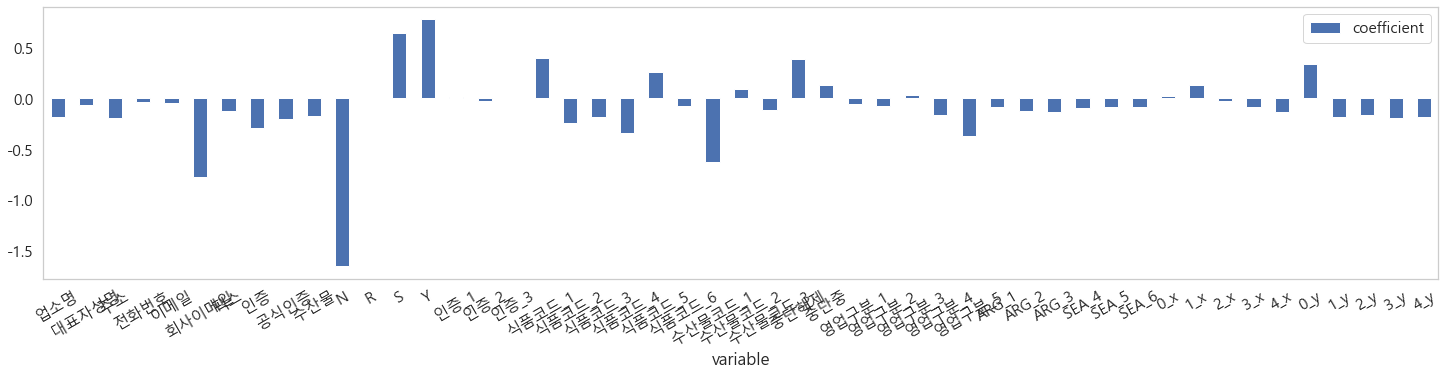

In [291]:
data = zip(X_train.columns, np.squeeze(model.coef_))
(pd.DataFrame(data, columns =['variable', 'coefficient']).set_index('variable').
plot.bar(rot='30', figsize=(25,5)))

## 선형모델(Logistic Regression) Interpretability, Explainability
- 검증데이터 첫번쨰를 예측해보고 설명해보자

In [292]:
from math import e
e
model.intercept_, model.coef_

2.718281828459045

(array([-0.2112255]),
 array([[-0.18631326, -0.06586149, -0.19341218, -0.03990497, -0.04515046,
         -0.77955878, -0.12936339, -0.28935927, -0.20104196, -0.17958364,
         -1.65343352,  0.        ,  0.63763798,  0.77970925,  0.01295805,
         -0.02412503, -0.0022077 ,  0.39571173, -0.24789818, -0.18580592,
         -0.34307406,  0.25786415, -0.0739005 , -0.63256155,  0.09532676,
         -0.11744749,  0.3906933 ,  0.1284761 , -0.05423357, -0.0797598 ,
          0.02891606, -0.16481299, -0.37230382, -0.08378207, -0.12559971,
         -0.13792933, -0.09525216, -0.08378207, -0.08378207,  0.0254482 ,
          0.12906193, -0.0237198 , -0.08169388, -0.13677562,  0.33308194,
         -0.1874523 , -0.1621521 , -0.18979905, -0.18235226]]))

In [293]:
X_test.head(2)

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,0_x,1_x,2_x,3_x,4_x,0_y,1_y,2_y,3_y,4_y
PH000000085,True,True,True,True,True,True,True,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,1.056266,0.035333,0.138500,-0.026006
ID000006157,True,True,True,True,True,False,True,False,False,True,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,0.827478,0.060730,0.095221,0.006533


In [294]:
model.coef_ * X_test.iloc[0].values
minus_beta_X = np.sum(model.coef_ * X_test.iloc[0].values)

array([[-0.1863132608519953, -0.0658614923028451, -0.19341217850686326,
        -0.03990496646601933, -0.045150463764735825, -0.7795587826589577,
        -0.12936339006263745, -0.0, -0.0, -0.0, -1.6534335207026258, 0.0,
        0.0, 0.0, 0.02591610054149524, -0.04825005076279503,
        -0.00441540051772539, 0.0, -0.0, -0.0, -0.3430740606356201, 0.0,
        -0.0, -0.0, 0.0, -0.0, 0.7813866094930535, 0.25695220878672237,
        -0.0, -0.0, 0.0, -0.0, -0.3723038217277183, -0.0, -0.0, -0.0,
        -0.0, -0.0, -0.0, -0.02317305014251398, 4.099572866567291e-05,
        4.390300875972393e-05, 3.8561703142855144e-05,
        0.00011090002924727908, -0.14657103195414864,
        -0.19799945573916491, -0.00572929407010687, -0.02628707910133473,
        0.004742316413797002]], dtype=object)

# Approaches: Statistics vs. Machine Learning
<img src='https://miro.medium.com/max/875/1*k_3rh-3zr_ebX06vFSkZHw.png'>
<img src = 'https://miro.medium.com/max/875/1*eJYDfncrjRfXXZn2b2MSbQ.png'>

# SHAP
## model agnostic interpretability (eXAI)
## SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model
https://github.com/slundberg/shap

<img src='https://raw.githubusercontent.com/slundberg/shap/master/docs/artwork/shap_header.svg' width=600 height=400>

In [297]:
import xgboost
import shap
# train an XGBoost model
#X, y =shap.datasets.adult()
X.head(10)
y[0:10]

,업소명,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,...,0_x,1_x,2_x,3_x,4_x,0_y,1_y,2_y,3_y,4_y
CN000095375,True,True,True,True,True,False,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
CN000010833,True,True,True,True,True,False,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
VN000000420,True,True,True,True,True,True,True,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
JP000002818,True,True,True,True,True,True,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
TH000001271,True,True,True,True,True,False,True,True,True,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,2.272495,5.974820e-15,8.636016e-17,2.075400e-16,6.774257e-18
VN000000995,True,True,True,True,True,True,True,True,True,False,...,1.098390,-0.204454,0.008652,0.066722,-0.138404,2.272495,5.974820e-15,8.636016e-17,2.075400e-16,6.774257e-18
ID000001276,True,True,True,True,True,False,False,False,False,False,...,-0.910597,0.000318,-0.001851,-0.000472,-0.000811,2.272495,5.974820e-15,8.636016e-17,2.075400e-16,6.774257e-18
US000001815,True,True,True,True,True,True,False,False,False,False,...,1.098556,-0.028765,-0.175403,0.284283,0.018275,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
VN000002079,True,True,True,True,True,True,True,False,False,False,...,1.097740,-0.076560,-0.214440,0.297290,0.122364,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02
TH000000292,True,True,True,True,True,True,True,True,True,False,...,1.098395,-0.357212,0.072732,-0.156156,0.173840,-0.440045,-1.845823e-01,-5.157423e-02,-2.323784e-01,-1.652735e-02


해외제조업소_코드
CN000095375    False
CN000010833    False
VN000000420    False
JP000002818    False
TH000001271    False
VN000000995    False
ID000001276     True
US000001815    False
VN000002079    False
TH000000292    False
Name: target, dtype: bool

In [ ]:
model = xgboost.XGBClassifier(eval_metric='mlogloss').fit(X, y)
explainer = shap.Explainer(model) # explainer = shap.Explainer(model, X)

In [299]:
model = dt.fit(X, y)
explainer = shap.Explainer(model) # explainer = shap.Explainer(model, X)

shap_values = explainer(X)
shap_values[0]
shap.plots.waterfall(shap_values[0])
shap.plots.waterfall(shap_values[6])

.values =
array([[ 0.00000000e+00,  0.00000000e+00],
       [ 6.24003279e-05, -6.24003279e-05],
       [-1.18698411e-04,  1.18698411e-04],
       [-2.60956114e-04,  2.60956114e-04],
       [-4.64050580e-04,  4.64050580e-04],
       [-4.83092270e-02,  4.83092270e-02],
       [ 1.34223737e-02, -1.34223737e-02],
       [ 1.04559111e-03, -1.04559111e-03],
       [-7.09391906e-03,  7.09391906e-03],
       [-2.58005970e-03,  2.58005970e-03],
       [ 4.28237274e-02, -4.28237274e-02],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 1.84538917e-02, -1.84538917e-02],
       [ 2.39408662e-02, -2.39408662e-02],
       [ 4.36827901e-03, -4.36827901e-03],
       [ 2.64799224e-03, -2.64799224e-03],
       [ 6.25103666e-04, -6.25103666e-04],
       [ 2.01783030e-02, -2.01783030e-02],
       [-2.06488589e-03,  2.06488589e-03],
       [-5.80432910e-04,  5.80432910e-04],
       [-6.28408523e-03,  6.28408523e-03],
       [ 1.26167945e-04, -1.26167945e-04],
       [-6.94901374e-04,  6.94901374e-04],
 

Exception: waterfall_plot requires a scalar base_values of the model output as the first parameter, but you have passed an array as the first parameter! Try shap.waterfall_plot(explainer.base_values[0], values[0], X[0]) or for multi-output models try shap.waterfall_plot(explainer.base_values[0], values[0][0], X[0]).

In [ ]:
explainer = shap.TreeExplainer(model) 
shap_values = explainer.shap_values(X)

In [302]:
shap.initjs()
shap.plots.force(explainer.expected_value[0], shap_values[0])

In [303]:
shap_values
print(f'\n\n원자료의 크기{X.shape}와 SHAP value의 크기{shap_values.shape}')

[array([[ 0.00000000e+00,  6.24003279e-05, -1.18698411e-04, ...,
         -2.15562981e-03, -1.88295016e-03,  3.85595293e-03],
        [ 0.00000000e+00, -5.33084288e-05, -8.51640363e-04, ...,
          2.74536474e-03,  2.95180107e-03,  1.08344844e-02],
        [ 0.00000000e+00, -1.18054067e-06,  3.73289968e-05, ...,
         -2.06715837e-04, -5.71419289e-04,  2.80842721e-03],
        ...,
        [ 0.00000000e+00, -1.42721414e-05,  2.49905196e-05, ...,
          1.07158582e-03,  9.85590525e-04,  4.29664537e-03],
        [ 0.00000000e+00, -4.30155507e-05, -2.38007836e-05, ...,
         -1.39115426e-05, -1.39369745e-03,  2.96047867e-03],
        [ 0.00000000e+00, -8.26372442e-06, -5.15286119e-03, ...,
         -1.33879693e-03, -1.24245366e-03,  3.37210199e-03]]),
 array([[ 0.00000000e+00, -6.24003279e-05,  1.18698411e-04, ...,
          2.15562981e-03,  1.88295016e-03, -3.85595293e-03],
        [ 0.00000000e+00,  5.33084288e-05,  8.51640363e-04, ...,
         -2.74536474e-03, -2.95180107e

AttributeError: 'list' object has no attribute 'shape'

In [304]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['sum of SHAP'] = data.sum(1)  # 특성 변수의 SHAP values
data['average mean of model prediction'] = np.mean(model.predict(X))
data['prediction value by shap'] = data['sum of SHAP'] + data['average mean of model prediction']
#data['prediction by model'] = model.predict(X)
data['prediction by model'] = model.predict(X)

ValueError: Must pass 2-d input. shape=(2, 1689, 49)

In [81]:
data.head(10)
shap_values[0]
shap_values[6]

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,sum of SHAP,average mean of model prediction,prediction value by shap,prediction by model
0,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,0.123742,0.685161,False
1,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,0.123742,0.685161,False
2,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,0.123742,0.666192,False
3,0.585718,0.017044,0.0,0.027914,0.014736,-0.739285,0.221285,0.127990,-0.146016,0.136975,-0.846611,-0.146402,-0.012618,-0.759267,0.123742,-0.635526,False
4,-1.110362,0.101956,0.0,0.028917,0.013844,-0.227823,0.346178,-0.375246,-0.224441,0.301570,2.637660,-0.631118,-0.096579,0.764558,0.123742,0.888300,False
5,0.515115,0.013862,0.0,0.023515,0.007797,-0.362927,0.001776,-0.213104,-0.150873,0.282640,-0.635336,-0.137353,0.008628,-0.646259,0.123742,-0.522517,False
6,0.489279,0.116791,0.0,0.025635,0.010510,0.211129,0.022459,-0.019946,0.005031,0.518182,3.924726,1.642316,0.011227,6.957340,0.123742,7.081082,True
7,0.250316,0.018135,0.0,0.029180,0.014811,-0.158309,0.170004,0.216376,-0.011563,0.171818,-0.905716,-0.142065,0.019977,-0.327036,0.123742,-0.203294,False
8,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,0.123742,0.666192,False
9,-0.484401,0.013681,0.0,0.030063,0.012861,-0.161747,0.133142,-0.104062,0.107809,0.234924,-0.719495,-0.146510,0.008029,-1.075706,0.123742,-0.951964,False


array([ 0.02356417,  0.0148988 ,  0.        ,  0.02944477,  0.01568345,
        0.5950321 ,  0.04651415, -0.0448022 ,  0.18699121,  0.35866883,
       -0.5529252 , -0.08078138, -0.0308699 ], dtype=float32)

array([ 0.4892791 ,  0.11679139,  0.        ,  0.02563503,  0.01051034,
        0.21112876,  0.02245855, -0.0199459 ,  0.00503143,  0.51818246,
        3.9247265 ,  1.642316  ,  0.01122656], dtype=float32)

In [82]:
data = pd.DataFrame(shap_values, columns = X.columns)
data['SUM'] = data.sum(1)  # 특성 변수의 SHAP values
data['f(x)'] = model.predict(X)
data['E[f(x)]'] = np.mean(model.predict(X))
data['SUM + E[f(x)]'] = data['SUM'] + data['E[f(x)]']
data.head(10)

,A02_국가코드,대표자성명,주소,전화번호,이메일,회사이메일,팩스,인증,공식인증,수산물,N,S,Y,SUM,f(x),E[f(x)],SUM + E[f(x)]
0,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,False,0.123742,0.685161
1,0.023564,0.014899,0.0,0.029445,0.015683,0.595032,0.046514,-0.044802,0.186991,0.358669,-0.552925,-0.080781,-0.030870,0.561419,False,0.123742,0.685161
2,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,False,0.123742,0.666192
3,0.585718,0.017044,0.0,0.027914,0.014736,-0.739285,0.221285,0.127990,-0.146016,0.136975,-0.846611,-0.146402,-0.012618,-0.759267,False,0.123742,-0.635526
4,-1.110362,0.101956,0.0,0.028917,0.013844,-0.227823,0.346178,-0.375246,-0.224441,0.301570,2.637660,-0.631118,-0.096579,0.764558,False,0.123742,0.888300
5,0.515115,0.013862,0.0,0.023515,0.007797,-0.362927,0.001776,-0.213104,-0.150873,0.282640,-0.635336,-0.137353,0.008628,-0.646259,False,0.123742,-0.522517
6,0.489279,0.116791,0.0,0.025635,0.010510,0.211129,0.022459,-0.019946,0.005031,0.518182,3.924726,1.642316,0.011227,6.957340,True,0.123742,7.081082
7,0.250316,0.018135,0.0,0.029180,0.014811,-0.158309,0.170004,0.216376,-0.011563,0.171818,-0.905716,-0.142065,0.019977,-0.327036,False,0.123742,-0.203294
8,1.261511,0.014837,0.0,0.023556,0.008004,-0.365345,-0.173035,0.109723,0.054790,0.333690,-0.609078,-0.126599,0.010397,0.542450,False,0.123742,0.666192
9,-0.484401,0.013681,0.0,0.030063,0.012861,-0.161747,0.133142,-0.104062,0.107809,0.234924,-0.719495,-0.146510,0.008029,-1.075706,False,0.123742,-0.951964


In [310]:
shap.initjs()
shap.force_plot(explainer.expected_value,)

Exception: In v0.20 force_plot now requires the base value as the first parameter! Try shap.force_plot(explainer.expected_value, shap_values) or for multi-output models try shap.force_plot(explainer.expected_value[0], shap_values[0]).

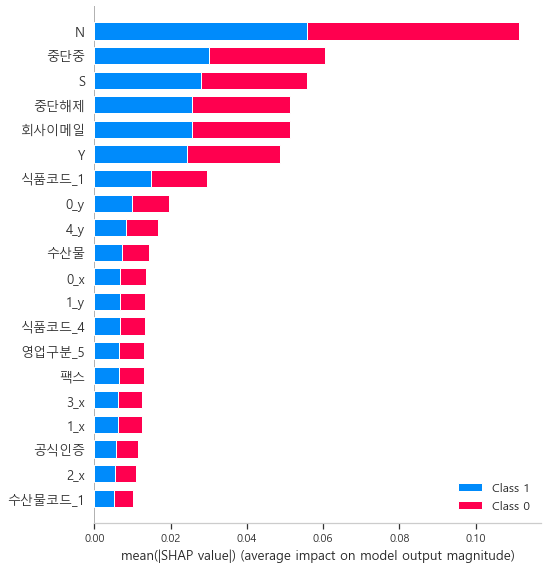

In [307]:
shap.summary_plot(shap_values, X)

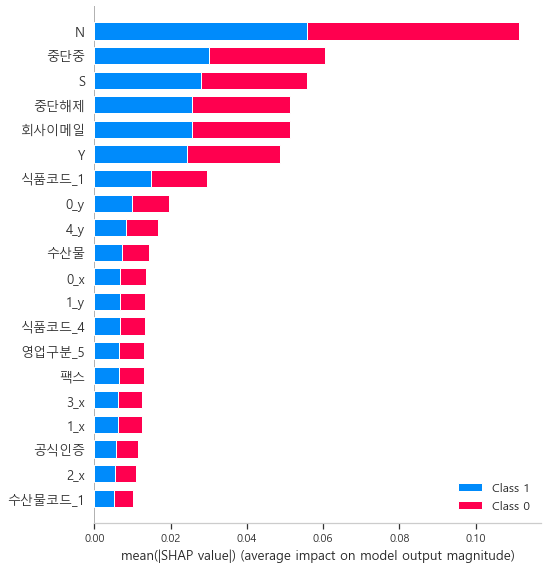

In [308]:
shap.summary_plot(shap_values, X, plot_type="bar")

# End